# TCN-MLP Evaluation Notebook (9 Climate Features)

This notebook evaluates the saved TCN-MLP model variants, quantifies uncertainty, and exports thesis-ready tables and figures.

It reuses the 9-feature monthly climate tensor and the crop-region context encoding from the training notebooks.

In [1]:
# Imports, optional explainability setup, and reproducibility
import os
import json
import random
import subprocess
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from scipy import stats
import matplotlib.pyplot as plt

try:
    import shap
except Exception:
    print('SHAP not found. Installing shap...')
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'shap'])
    import shap

SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

plt.rcParams['figure.dpi'] = 160
plt.rcParams['savefig.dpi'] = 320
plt.rcParams['font.size'] = 11

print('TensorFlow:', tf.__version__)
print('SHAP:', shap.__version__)
print('Seed set to', SEED)

TensorFlow: 2.20.0
SHAP: 0.50.0
Seed set to 42


In [2]:
# Paths, features, and model registry
DATA_PATH = '../data/processed_dataset.csv'
MODELS_DIR = Path('../models')
RESULTS_DIR = Path('../results')
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

CLIMATE_FEATURES = [
    'T2M',
    'T2M_MAX',
    'T2M_MIN',
    'TS',
    'T2MDEW',
    'T2MWET',
    'PRECTOTCORR',
    'RH2M',
    'QV2M',
]
FEATURE_GROUPS = {
    'Temperature': ['T2M', 'T2M_MAX', 'T2M_MIN', 'TS'],
    'Precipitation': ['PRECTOTCORR'],
    'Humidity': ['RH2M', 'QV2M', 'T2MDEW', 'T2MWET'],
}

"""
Category,       Parameter_Code, Parameter_Name,         Unit
temperature,    T2M,            Mean temperature at 2m, °C
temperature,    T2M_MAX,        Max temperature at 2m,  °C
temperature,    T2M_MIN,        Min temperature at 2m,  °C
temperature,    TS,             land surface temperature,°C
rainfall,       PRECTOTCORR,    Bias-corrected total precipitation,mm/day
humidity,       RH2M,           Relative humidity at 2m,%
humidity,       QV2M,           Specific humidity at 2m,g/kg
humidity,       T2MDEW,         Dew point temperature at 2m,°C
humidity,       T2MWET,         Wet bulb temperature at 2m,°C
"""
MONTH_NAMES = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
N_MONTHS = 12
N_FEATURES = len(CLIMATE_FEATURES)
N_FOLDS = 5
EPSILON = 1e-6
PRIMARY_MODEL_NAME = 'TCN_MLP_ENSEMBLE'
MODEL_CANDIDATES = [
    (PRIMARY_MODEL_NAME, MODELS_DIR / 'TCN_MLP_ENSEMBLE.keras', None),
]

print('Results dir:', RESULTS_DIR.resolve())
print('Model dir:', MODELS_DIR.resolve())
print('Climate features:', CLIMATE_FEATURES)

Results dir: C:\Users\ibito\Downloads\project_test\New_Changes\results
Model dir: C:\Users\ibito\Downloads\project_test\New_Changes\models
Climate features: ['T2M', 'T2M_MAX', 'T2M_MIN', 'TS', 'T2MDEW', 'T2MWET', 'PRECTOTCORR', 'RH2M', 'QV2M']


In [3]:
# Load data and reconstruct the monthly climate tensor
df = pd.read_csv(DATA_PATH)
df = df.dropna(subset=['Yield_kg_per_ha']).copy()

required_cols = []
for month in range(1, N_MONTHS + 1):
    for feature in CLIMATE_FEATURES:
        required_cols.append(f'{feature}_m{month}')
missing_cols = [col for col in required_cols if col not in df.columns]
if missing_cols:
    raise ValueError(f'Missing required columns: {missing_cols[:10]} ... total={len(missing_cols)}')

def build_sequence_tensor(frame):
    tensor = np.zeros((frame.shape[0], N_MONTHS, N_FEATURES), dtype=np.float32)
    for month in range(1, N_MONTHS + 1):
        for idx, feature in enumerate(CLIMATE_FEATURES):
            tensor[:, month - 1, idx] = frame[f'{feature}_m{month}'].values
    return tensor

def build_year_features(year_values):
    """Matches training notebook: ONLY returns time features (Norm, Sin, Cos)."""
    y_norm = ((year_values.reshape(-1, 1) - 1999.0) / 24.0).astype(np.float32)
    y_sin = np.sin(2.0 * np.pi * y_norm).astype(np.float32)
    y_cos = np.cos(2.0 * np.pi * y_norm).astype(np.float32)
    return np.column_stack([y_norm, y_sin, y_cos]).astype(np.float32)

def safe_mape(y_true, y_pred):
    denom = np.where(np.abs(y_true) < EPSILON, EPSILON, np.abs(y_true))
    return float(np.mean(np.abs((y_true - y_pred) / denom)) * 100.0)

def safe_smape(y_true, y_pred):
    denom = np.abs(y_true) + np.abs(y_pred)
    denom = np.where(denom < EPSILON, EPSILON, denom)
    return float(np.mean(2.0 * np.abs(y_pred - y_true) / denom) * 100.0)

def safe_mase(y_true, y_pred, naive_pred):
    mae = mean_absolute_error(y_true, y_pred)
    naive_mae = mean_absolute_error(y_true, naive_pred)
    return float(mae / naive_mae) if naive_mae > 0 else np.nan

def compute_skill_score(y_true, y_pred, baseline_pred):
    mse_model = np.mean((y_true - y_pred) ** 2)
    mse_base = np.mean((y_true - baseline_pred) ** 2)
    return float(1.0 - (mse_model / mse_base)) if mse_base > 0 else np.nan

def compare_models(y_true, y_pred_model1, y_pred_model2):
    e1 = y_true - y_pred_model1
    e2 = y_true - y_pred_model2
    diff = e1**2 - e2**2
    t_stat, p_val = stats.ttest_1samp(diff, 0.0)
    return {
        't_statistic': float(t_stat),
        'p_value': float(p_val),
        'model1_better': bool(np.mean(e1**2) < np.mean(e2**2)),
    }

def compute_prediction_uncertainty(predictions_list):
    predictions_array = np.stack(predictions_list, axis=1)
    mean_pred = np.mean(predictions_array, axis=1)
    std_pred = np.std(predictions_array, axis=1)
    ci_lower = mean_pred - 1.96 * std_pred
    ci_upper = mean_pred + 1.96 * std_pred
    return mean_pred, std_pred, ci_lower, ci_upper

y_raw = df['Yield_kg_per_ha'].values.astype(np.float32)
years = df['Year'].values.astype(np.float32)
region_to_id = {region: idx for idx, region in enumerate(sorted(df['Region'].unique()))}
crop_to_id = {crop: idx for idx, crop in enumerate(sorted(df['Crop'].unique()))}
region_ids = np.array([region_to_id[value] for value in df['Region'].values], dtype=np.int32)
crop_ids = np.array([crop_to_id[value] for value in df['Crop'].values], dtype=np.int32)
X_seq = build_sequence_tensor(df)
y_log = np.log(y_raw + EPSILON)
strat_labels = np.array([f'{crop}_{region}' for crop, region in zip(crop_ids, region_ids)])
skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)
folds = list(skf.split(X_seq, strat_labels))

print('Dataset samples:', df.shape[0])
print('X_seq shape:', X_seq.shape)
print('Crop classes:', crop_to_id)
print('Region classes:', region_to_id)

Dataset samples: 600
X_seq shape: (600, 12, 9)
Crop classes: {'Cassava': 0, 'Maize': 1, 'Rice': 2, 'Yam': 3}
Region classes: {'North-Central': 0, 'North-East': 1, 'North-West': 2, 'South-East': 3, 'South-South': 4, 'South-West': 5}


In [4]:
# Load the requested ensemble model and its metadata

def load_model_metadata(metadata_path):
    if metadata_path is None or not Path(metadata_path).exists():
        return {}
    with open(metadata_path, 'r', encoding='utf-8') as handle:
        return json.load(handle)


def load_model_bundle(name, model_path, metadata_path=None):
    model_path = Path(model_path)
    if not model_path.exists():
        raise FileNotFoundError(f'Model file not found: {model_path}')
    model = keras.models.load_model(model_path, compile=False)
    return {
        'name': name,
        'path': str(model_path),
        'model': model,
        'metadata': load_model_metadata(metadata_path),
    }


loaded_models = {}
model_inventory = []
primary_model_path = MODELS_DIR / 'TCN_MLP_ENSEMBLE.keras'
model_bundle = load_model_bundle(PRIMARY_MODEL_NAME, primary_model_path, None)
loaded_models[PRIMARY_MODEL_NAME] = model_bundle
model_inventory.append({
    'Model': PRIMARY_MODEL_NAME,
    'Path': str(primary_model_path),
    'MetadataPath': '',
    'HasMetadata': False,
})

model_inventory_df = pd.DataFrame(model_inventory)
model_inventory_df.to_csv(RESULTS_DIR / 'tcn_mlp_model_inventory.csv', index=False)

print('Loaded models:', list(loaded_models.keys()))
print('Primary model:', PRIMARY_MODEL_NAME)

Loaded models: ['TCN_MLP_ENSEMBLE']
Primary model: TCN_MLP_ENSEMBLE


In [12]:
# Fold-ensemble evaluation using saved fold models


def load_model_metadata(metadata_path):
    if metadata_path is None or not Path(metadata_path).exists():
        return {}
    with open(metadata_path, 'r', encoding='utf-8') as handle:
        return json.load(handle)


def load_model_bundle(name, model_path, metadata_path=None):
    model_path = Path(model_path)
    if not model_path.exists():
        raise FileNotFoundError(f'Model file not found: {model_path}')
    model = keras.models.load_model(model_path, compile=False)
    return {
        'name': name,
        'path': str(model_path),
        'model': model,
        'metadata': load_model_metadata(metadata_path),
    }


def fit_fold_transforms(train_idx, test_idx):
    X_train_raw = X_seq[train_idx]
    X_test_raw = X_seq[test_idx]
    y_train_raw = y_raw[train_idx]
    y_test_raw = y_raw[test_idx]
    y_train_log = y_log[train_idx]
    y_test_log = y_log[test_idx]
    r_train = region_ids[train_idx]
    r_test = region_ids[test_idx]
    c_train = crop_ids[train_idx]
    c_test = crop_ids[test_idx]
    yr_train_raw = build_year_features(years[train_idx])
    yr_test_raw = build_year_features(years[test_idx])

    x_scaler = StandardScaler()
    X_train = x_scaler.fit_transform(X_train_raw.reshape(-1, N_FEATURES)).reshape(X_train_raw.shape).astype(np.float32)
    X_test = x_scaler.transform(X_test_raw.reshape(-1, N_FEATURES)).reshape(X_test_raw.shape).astype(np.float32)

    year_scaler = StandardScaler()
    yr_train_scaled = year_scaler.fit_transform(yr_train_raw).astype(np.float32)
    yr_test_scaled = year_scaler.transform(yr_test_raw).astype(np.float32)

    crop_log_mean = np.zeros(len(crop_to_id), dtype=np.float32)
    crop_log_std = np.zeros(len(crop_to_id), dtype=np.float32)
    crop_raw_mean = np.zeros(len(crop_to_id), dtype=np.float32)
    for cid in range(len(crop_to_id)):
        mask = c_train == cid
        log_vals = y_train_log[mask]
        raw_vals = y_train_raw[mask]
        crop_log_mean[cid] = float(np.mean(log_vals))
        crop_log_std[cid] = float(max(np.std(log_vals), 1e-3))
        crop_raw_mean[cid] = float(np.mean(raw_vals))

    y_train_norm = (y_train_log - crop_log_mean[c_train]) / crop_log_std[c_train]
    y_test_norm = (y_test_log - crop_log_mean[c_test]) / crop_log_std[c_test]

    return {
        'X_train': X_train,
        'X_test': X_test,
        'y_train_raw': y_train_raw,
        'y_test_raw': y_test_raw,
        'y_train_norm': y_train_norm,
        'y_test_norm': y_test_norm,
        'r_train': r_train,
        'r_test': r_test,
        'c_train': c_train,
        'c_test': c_test,
        'yr_train': yr_train_scaled,
        'yr_test': yr_test_scaled,
        'crop_log_mean': crop_log_mean,
        'crop_log_std': crop_log_std,
        'crop_raw_mean': crop_raw_mean,
        'train_idx': train_idx,
        'test_idx': test_idx,
    }


loaded_models = {}
model_inventory = []
fold_model_paths = sorted(MODELS_DIR.glob('tcn_mlp_fold_*.keras'))
best_fold_model_path = MODELS_DIR / 'TCN_MLP_ENSEMBLE_best_fold.keras'

if best_fold_model_path.exists():
    loaded_models[PRIMARY_MODEL_NAME] = load_model_bundle(PRIMARY_MODEL_NAME, best_fold_model_path, None)
    model_inventory.append({
        'Model': PRIMARY_MODEL_NAME,
        'Path': str(best_fold_model_path),
        'MetadataPath': '',
        'HasMetadata': False,
        'Role': 'primary_best_fold',
    })

for fold_path in fold_model_paths:
    fold_name = f'Fold_{fold_path.stem.split("_")[-1]}'
    loaded_models[fold_name] = load_model_bundle(fold_name, fold_path, None)
    model_inventory.append({
        'Model': fold_name,
        'Path': str(fold_path),
        'MetadataPath': '',
        'HasMetadata': False,
        'Role': 'ensemble_member',
    })

if PRIMARY_MODEL_NAME not in loaded_models:
    if not fold_model_paths:
        raise FileNotFoundError(f'No fold models found in {MODELS_DIR}')
    first_fold_path = fold_model_paths[0]
    loaded_models[PRIMARY_MODEL_NAME] = load_model_bundle(PRIMARY_MODEL_NAME, first_fold_path, None)
    model_inventory.append({
        'Model': PRIMARY_MODEL_NAME,
        'Path': str(first_fold_path),
        'MetadataPath': '',
        'HasMetadata': False,
        'Role': 'primary_fallback',
    })

model_inventory_df = pd.DataFrame(model_inventory)
model_inventory_df.to_csv(RESULTS_DIR / 'tcn_mlp_model_inventory.csv', index=False)

print('Loaded models:', list(loaded_models.keys()))
print('Primary model:', PRIMARY_MODEL_NAME)


fold_metrics_rows = []
sample_prediction_rows = []
primary_vs_ensemble_errors = []
fold_prediction_cache = []

ensemble_model_names = [name for name in loaded_models.keys() if name.startswith('Fold_')]
ensemble_model_names.sort(key=lambda name: int(name.split('_')[1]))
if not ensemble_model_names:
    ensemble_model_names = [PRIMARY_MODEL_NAME]

for fold_id, (train_idx, test_idx) in enumerate(folds, start=1):
    split = fit_fold_transforms(train_idx, test_idx)

    fold_predictions = {}
    ensemble_pred_inputs = []
    for model_name in ensemble_model_names:
        model_bundle = loaded_models[model_name]
        pred_norm = model_bundle['model'].predict([split['X_test'], split['r_test'], split['c_test'], split['yr_test']], verbose=0).ravel()
        pred_log = pred_norm * split['crop_log_std'][split['c_test']] + split['crop_log_mean'][split['c_test']]
        pred_raw = np.exp(pred_log)
        fold_predictions[model_name] = {
            'pred_norm': pred_norm,
            'pred_log': pred_log,
            'pred_raw': pred_raw,
        }
        ensemble_pred_inputs.append(pred_raw)

    primary_bundle = loaded_models[PRIMARY_MODEL_NAME]
    primary_pred_norm = primary_bundle['model'].predict([split['X_test'], split['r_test'], split['c_test'], split['yr_test']], verbose=0).ravel()
    primary_pred_log = primary_pred_norm * split['crop_log_std'][split['c_test']] + split['crop_log_mean'][split['c_test']]
    primary_pred = np.exp(primary_pred_log)
    fold_predictions[PRIMARY_MODEL_NAME] = {
        'pred_norm': primary_pred_norm,
        'pred_log': primary_pred_log,
        'pred_raw': primary_pred,
    }

    ensemble_pred, ensemble_std, ensemble_ci_low, ensemble_ci_high = compute_prediction_uncertainty(ensemble_pred_inputs)
    baseline_pred = split['crop_raw_mean'][split['c_test']]

    fold_row = {
        'Fold': fold_id,
        'Test_Samples': int(len(split['test_idx'])),
        'Primary_R2': float(r2_score(split['y_test_raw'], primary_pred)),
        'Primary_MAE': float(mean_absolute_error(split['y_test_raw'], primary_pred)),
        'Primary_RMSE': float(np.sqrt(mean_squared_error(split['y_test_raw'], primary_pred))),
        'Primary_MAPE': safe_mape(split['y_test_raw'], primary_pred),
        'Primary_sMAPE': safe_smape(split['y_test_raw'], primary_pred),
        'Primary_MASE': safe_mase(split['y_test_raw'], primary_pred, baseline_pred),
        'Ensemble_R2': float(r2_score(split['y_test_raw'], ensemble_pred)),
        'Ensemble_MAE': float(mean_absolute_error(split['y_test_raw'], ensemble_pred)),
        'Ensemble_RMSE': float(np.sqrt(mean_squared_error(split['y_test_raw'], ensemble_pred))),
        'Ensemble_MAPE': safe_mape(split['y_test_raw'], ensemble_pred),
        'Ensemble_sMAPE': safe_smape(split['y_test_raw'], ensemble_pred),
        'Ensemble_MASE': safe_mase(split['y_test_raw'], ensemble_pred, baseline_pred),
        'Ensemble_Std_Mean': float(np.mean(ensemble_std)),
        'Ensemble_Std_Median': float(np.median(ensemble_std)),
        'CI_Width_Mean': float(np.mean(ensemble_ci_high - ensemble_ci_low)),
        'Skill_Score': compute_skill_score(split['y_test_raw'], ensemble_pred, baseline_pred),
    }
    fold_metrics_rows.append(fold_row)

    comparison = compare_models(split['y_test_raw'], primary_pred, ensemble_pred)
    comparison.update({'Fold': fold_id})
    primary_vs_ensemble_errors.append(comparison)

    split_df = pd.DataFrame({
        'Fold': fold_id,
        'Sample_Index': split['test_idx'],
        'Crop': df.iloc[split['test_idx']]['Crop'].values,
        'Region': df.iloc[split['test_idx']]['Region'].values,
        'Year': df.iloc[split['test_idx']]['Year'].values,
        'Yield_True': split['y_test_raw'],
        'Yield_Primary': primary_pred,
        'Yield_Ensemble': ensemble_pred,
        'Yield_Std': ensemble_std,
        'Yield_CI_Low': ensemble_ci_low,
        'Yield_CI_High': ensemble_ci_high,
        'Crop_Baseline': baseline_pred,
    })
    split_df[f'Yield_{PRIMARY_MODEL_NAME}'] = primary_pred
    for model_name, pred_data in fold_predictions.items():
        split_df[f'Yield_{model_name}'] = pred_data['pred_raw']
    sample_prediction_rows.append(split_df)

    fold_prediction_cache.append({
        'fold': fold_id,
        'split': split,
        'predictions': fold_predictions,
        'primary_pred': primary_pred,
        'ensemble_pred': ensemble_pred,
        'ensemble_std': ensemble_std,
    })

    print(f"Fold {fold_id}: R²={fold_row['Ensemble_R2']:.4f} | MAE={fold_row['Ensemble_MAE']:.2f}")

fold_metrics_df = pd.DataFrame(fold_metrics_rows)
primary_vs_ensemble_df = pd.DataFrame(primary_vs_ensemble_errors)
all_predictions_df = pd.concat(sample_prediction_rows, ignore_index=True)

fold_metrics_df.to_csv(RESULTS_DIR / 'tcn_mlp_eval_fold_metrics.csv', index=False)
all_predictions_df.to_csv(RESULTS_DIR / 'tcn_mlp_eval_predictions.csv', index=False)
primary_vs_ensemble_df.to_csv(RESULTS_DIR / 'tcn_mlp_eval_model_comparison.csv', index=False)

print('Fold evaluation complete.')
fold_metrics_df

Loaded models: ['TCN_MLP_ENSEMBLE', 'Fold_1', 'Fold_2', 'Fold_3', 'Fold_4', 'Fold_5']
Primary model: TCN_MLP_ENSEMBLE
Fold 1: R²=0.8195 | MAE=871.24
Fold 2: R²=0.8991 | MAE=830.29
Fold 3: R²=0.8962 | MAE=917.54
Fold 4: R²=0.8314 | MAE=1068.10
Fold 5: R²=0.7221 | MAE=1050.33
Fold evaluation complete.


,Fold,Test_Samples,Primary_R2,Primary_MAE,Primary_RMSE,Primary_MAPE,Primary_sMAPE,Primary_MASE,Ensemble_R2,Ensemble_MAE,Ensemble_RMSE,Ensemble_MAPE,Ensemble_sMAPE,Ensemble_MASE,Ensemble_Std_Mean,Ensemble_Std_Median,CI_Width_Mean,Skill_Score
0,1,120,0.930693,708.341553,1411.238020,12.336243,11.741986,0.457539,0.819491,871.237915,2277.507080,14.204184,13.050447,0.562758,698.536072,280.419861,2738.261475,0.549360
1,2,120,0.912512,725.524475,1378.035014,13.385299,12.175218,0.449042,0.899067,830.288879,1480.140112,15.638523,13.876942,0.513882,442.636017,321.466309,1735.133057,0.655249
2,3,120,0.843196,1046.576416,1804.928323,17.920767,17.131891,0.674887,0.896159,917.544922,1468.814062,15.862463,15.240963,0.591680,450.473145,193.506958,1765.854736,0.593345
3,4,120,0.892594,895.955688,1827.841281,12.317732,12.521134,0.508686,0.831408,1068.095581,2290.038864,15.011033,14.781457,0.606420,495.408112,242.043091,1941.999878,0.580028
4,5,120,0.747210,934.745789,2786.958198,12.185655,12.487612,0.510645,0.722123,1050.326050,2921.976386,14.685824,14.642718,0.573785,475.928589,306.790894,1865.640259,0.348268


In [13]:
# Overall summary tables and statistical tests
overall_summary = fold_metrics_df[['Primary_R2', 'Primary_MAE', 'Primary_RMSE', 'Primary_MAPE', 'Primary_sMAPE', 'Primary_MASE', 'Ensemble_R2', 'Ensemble_MAE', 'Ensemble_RMSE', 'Ensemble_MAPE', 'Ensemble_sMAPE', 'Ensemble_MASE', 'Ensemble_Std_Mean', 'CI_Width_Mean', 'Skill_Score']].agg(['mean', 'std']).T.reset_index()
overall_summary = overall_summary.rename(columns={'index': 'Metric', 'mean': 'Mean', 'std': 'Std'})
overall_summary.to_csv(RESULTS_DIR / 'tcn_mlp_eval_overall_summary.csv', index=False)

primary_errors = np.concatenate([cache['split']['y_test_raw'] - cache['predictions'][PRIMARY_MODEL_NAME]['pred_raw'] for cache in fold_prediction_cache])
ensemble_errors = np.concatenate([cache['split']['y_test_raw'] - cache['ensemble_pred'] for cache in fold_prediction_cache])
paired_test = compare_models(np.concatenate([cache['split']['y_test_raw'] for cache in fold_prediction_cache]), np.concatenate([cache['predictions'][PRIMARY_MODEL_NAME]['pred_raw'] for cache in fold_prediction_cache]), np.concatenate([cache['ensemble_pred'] for cache in fold_prediction_cache]))

coverage_mask = (all_predictions_df['Yield_True'].values >= all_predictions_df['Yield_CI_Low'].values) & (all_predictions_df['Yield_True'].values <= all_predictions_df['Yield_CI_High'].values)
picp = float(np.mean(coverage_mask))
baseline_mae = float(mean_absolute_error(all_predictions_df['Yield_True'], all_predictions_df['Crop_Baseline']))
primary_mae = float(mean_absolute_error(all_predictions_df['Yield_True'], all_predictions_df[f'Yield_{PRIMARY_MODEL_NAME}']))
ensemble_mae = float(mean_absolute_error(all_predictions_df['Yield_True'], all_predictions_df['Yield_Ensemble']))

calibration_frame = all_predictions_df[['Yield_True', 'Yield_Ensemble']].copy()
calibration_frame['Pred_Bin'] = pd.qcut(calibration_frame['Yield_Ensemble'], q=min(10, calibration_frame.shape[0]), duplicates='drop')
calibration_rows = []
for pred_bin, group in calibration_frame.groupby('Pred_Bin', observed=False):
    calibration_rows.append({
        'Pred_Bin': str(pred_bin),
        'Count': int(group.shape[0]),
        'Mean_Predicted': float(group['Yield_Ensemble'].mean()),
        'Mean_Actual': float(group['Yield_True'].mean()),
        'Abs_Gap': float(abs(group['Yield_Ensemble'].mean() - group['Yield_True'].mean())),
    })
calibration_df = pd.DataFrame(calibration_rows)
calibration_df.to_csv(RESULTS_DIR / 'tcn_mlp_eval_calibration.csv', index=False)

print('Overall fold summary:')
print(overall_summary.to_string(index=False))
print('Paired primary-vs-ensemble test:')
print(paired_test)
print(f'PICP: {picp:.4f}')
print(f'Baseline MAE: {baseline_mae:.2f} | Primary MAE: {primary_mae:.2f} | Ensemble MAE: {ensemble_mae:.2f}')

summary_table = pd.DataFrame({
    'Metric': ['Overall R2', 'Overall MAE', 'Overall RMSE', 'Overall MAPE', 'Overall sMAPE', 'Overall MASE', 'Mean Uncertainty', 'Mean CI Width', 'PICP', 'Baseline MAE', 'Primary MAE', 'Ensemble MAE', 'MAE Gain vs Primary'],
    'Value': [
        float(fold_metrics_df['Ensemble_R2'].mean()),
        float(fold_metrics_df['Ensemble_MAE'].mean()),
        float(fold_metrics_df['Ensemble_RMSE'].mean()),
        float(fold_metrics_df['Ensemble_MAPE'].mean()),
        float(fold_metrics_df['Ensemble_sMAPE'].mean()),
        float(fold_metrics_df['Ensemble_MASE'].mean()),
        float(all_predictions_df['Yield_Std'].mean()),
        float(all_predictions_df['Yield_CI_High'].sub(all_predictions_df['Yield_CI_Low']).mean()),
        picp,
        baseline_mae,
        primary_mae,
        ensemble_mae,
        primary_mae - ensemble_mae,
    ]
})
summary_table.to_csv(RESULTS_DIR / 'thesis_summary_table.csv', index=False)
try:
    summary_table.to_latex(RESULTS_DIR / 'thesis_summary_table.tex', index=False, float_format='%.3f')
except Exception as exc:
    print('LaTeX export skipped:', exc)

summary_table

Overall fold summary:
           Metric        Mean        Std
       Primary_R2    0.865241   0.073627
      Primary_MAE  862.228784 143.831166
     Primary_RMSE 1841.800167 569.065015
     Primary_MAPE   13.629139   2.447067
    Primary_sMAPE   13.211568   2.213789
     Primary_MASE    0.520159   0.091024
      Ensemble_R2    0.833649   0.072164
     Ensemble_MAE  947.498669 106.733488
    Ensemble_RMSE 2087.695301 617.481509
    Ensemble_MAPE   15.080405   0.680327
   Ensemble_sMAPE   14.318505   0.862165
    Ensemble_MASE    0.569705   0.035398
Ensemble_Std_Mean  512.596387 106.027451
    CI_Width_Mean 2009.377881 415.627639
      Skill_Score    0.545250   0.116663
Paired primary-vs-ensemble test:
{'t_statistic': -1.6857175463492304, 'p_value': 0.09237100361550128, 'model1_better': True}
PICP: 0.5583
Baseline MAE: 1661.29 | Primary MAE: 862.23 | Ensemble MAE: 947.50


,Metric,Value
0,Overall R2,0.833649
1,Overall MAE,947.498669
2,Overall RMSE,2087.695301
3,Overall MAPE,15.080405
4,Overall sMAPE,14.318505
5,Overall MASE,0.569705
6,Mean Uncertainty,512.596375
7,Mean CI Width,2009.377930
8,PICP,0.558333
9,Baseline MAE,1661.290894


In [7]:
# Per-crop and per-region summaries with resilience-style outputs
def aggregate_group_metrics(frame, group_col):
    rows = []
    for name, group in frame.groupby(group_col):
        y_true = group['Yield_True'].values
        y_pred = group['Yield_Ensemble'].values
        baseline = group['Crop_Baseline'].values
        rows.append({
            group_col: name,
            'Samples': int(len(group)),
            'R2': float(r2_score(y_true, y_pred)) if len(group) > 1 else np.nan,
            'MAE': float(mean_absolute_error(y_true, y_pred)),
            'RMSE': float(np.sqrt(mean_squared_error(y_true, y_pred))),
            'MAPE': safe_mape(y_true, y_pred),
            'sMAPE': safe_smape(y_true, y_pred),
            'MASE': safe_mase(y_true, y_pred, baseline),
            'Yield_Mean': float(np.mean(y_true)),
            'Yield_Std': float(np.std(y_true)),
            'Yield_CV': float(np.std(y_true) / np.mean(y_true)) if np.mean(y_true) > 0 else np.nan,
            'Resilience_Index': float(np.mean(y_true) / (np.std(y_true) + EPSILON)),
            'Mean_Uncertainty': float(group['Yield_Std'].mean()),
        })
    return pd.DataFrame(rows)

crop_perf_df = aggregate_group_metrics(all_predictions_df, 'Crop').sort_values('R2', ascending=False)
region_perf_df = aggregate_group_metrics(all_predictions_df, 'Region').sort_values('R2', ascending=False)
crop_region_perf_df = aggregate_group_metrics(all_predictions_df.assign(CropRegion=all_predictions_df['Crop'] + ' | ' + all_predictions_df['Region']), 'CropRegion')

crop_perf_df.to_csv(RESULTS_DIR / 'crop_ensemble_metrics.csv', index=False)
region_perf_df.to_csv(RESULTS_DIR / 'region_ensemble_metrics.csv', index=False)
crop_region_perf_df.to_csv(RESULTS_DIR / 'crop_region_resilience.csv', index=False)

print('Best crop by R2:', crop_perf_df.iloc[0]['Crop'])
print('Best region by R2:', region_perf_df.iloc[0]['Region'])
crop_perf_df
region_perf_df

Best crop by R2: Cassava
Best region by R2: South-West


,Region,Samples,R2,MAE,RMSE,MAPE,sMAPE,MASE,Yield_Mean,Yield_Std,Yield_CV,Resilience_Index,Mean_Uncertainty
5,South-West,100,0.909258,911.027527,1577.720904,13.659393,13.198034,0.591663,6647.366211,5237.510742,0.787908,1.269184,0.0
4,South-South,100,0.878605,728.133972,1384.241670,12.949337,13.261722,0.479262,5237.450195,3972.928955,0.758562,1.318284,0.0
2,North-West,100,0.869501,689.396973,1172.055886,14.966895,13.890571,0.456247,4633.967773,3244.472412,0.700150,1.428265,0.0
0,North-Central,100,0.868091,1292.953613,2498.974890,17.044077,15.112901,0.607329,7359.875000,6880.585938,0.934878,1.069658,0.0
1,North-East,100,0.866588,740.880066,1317.660711,13.934887,14.091866,0.524404,4843.726074,3607.504883,0.744779,1.342680,0.0
3,South-East,100,0.787614,810.980530,2854.404579,9.220249,9.714316,0.436963,7157.073730,6193.733887,0.865400,1.155535,0.0


In [8]:
# Climate sensitivity, lag analysis, anomaly impact, interaction strength, and error decomposition
def compute_crop_climate_sensitivity(frame, crop_name, feature, yield_col='Yield_kg_per_ha'):
    crop_data = frame[frame['Crop'] == crop_name].copy()
    correlations = []
    for month in range(1, N_MONTHS + 1):
        col = f'{feature}_m{month}'
        if col in crop_data.columns and len(crop_data) > 2:
            corr = crop_data[[col, yield_col]].corr().iloc[0, 1]
            correlations.append({'Month': month, 'Correlation': float(corr)})
    return pd.DataFrame(correlations)

def compute_climate_yield_lag(frame, crop_name, region_name, climate_feature, max_lag=3):
    mask = (frame['Crop'] == crop_name) & (frame['Region'] == region_name)
    data = frame[mask].copy()
    lags = {}
    if len(data) < 10:
        return lags
    annual = data.groupby('Year').agg({f'{climate_feature}_m6': 'mean', 'Yield_kg_per_ha': 'mean'}).dropna()
    for lag in range(max_lag + 1):
        shifted = annual[f'{climate_feature}_m6'].shift(lag)
        aligned = pd.DataFrame({'climate': shifted, 'yield': annual['Yield_kg_per_ha']}).dropna()
        if len(aligned) > 2:
            lags[lag] = float(aligned['climate'].corr(aligned['yield']))
    return lags

def compute_regional_climate_anomaly_impact(frame, region_name, baseline_years=(2000, 2010), feature='PRECTOTCORR'):
    region_data = frame[frame['Region'] == region_name].copy()
    if len(region_data) == 0:
        return pd.DataFrame()
    annual = region_data.groupby('Year').agg({f'{feature}_m6': 'mean', 'Yield_kg_per_ha': 'mean'}).dropna()
    baseline_mask = annual.index.to_series().between(*baseline_years)
    baseline = annual.loc[baseline_mask]
    if len(baseline) == 0:
        baseline = annual
    clim_mean = baseline[f'{feature}_m6'].mean()
    clim_std = baseline[f'{feature}_m6'].std() if baseline[f'{feature}_m6'].std() > 0 else 1.0
    annual = annual.copy()
    annual['Anomaly_Z'] = (annual[f'{feature}_m6'] - clim_mean) / clim_std
    annual['Anomaly_Class'] = pd.cut(annual['Anomaly_Z'], bins=[-np.inf, -1.0, 1.0, np.inf], labels=['Low', 'Normal', 'High'])
    return annual.groupby('Anomaly_Class')['Yield_kg_per_ha'].agg(['mean', 'count', 'std']).reset_index()

def estimate_crop_region_interaction(frame):
    model_frame = frame[['Yield_True', 'Crop', 'Region']].copy()
    model_frame['crop_code'] = pd.Categorical(model_frame['Crop']).codes.astype(float)
    model_frame['region_code'] = pd.Categorical(model_frame['Region']).codes.astype(float)
    model_frame['interaction'] = model_frame['crop_code'] * model_frame['region_code']
    X = np.column_stack([np.ones(len(model_frame)), model_frame['crop_code'], model_frame['region_code'], model_frame['interaction']])
    y = model_frame['Yield_True'].values.astype(float)
    coef, _, _, _ = np.linalg.lstsq(X, y, rcond=None)
    y_hat = X @ coef
    r2 = 1.0 - np.sum((y - y_hat) ** 2) / np.sum((y - np.mean(y)) ** 2)
    return {'interaction_coef': float(coef[-1]), 'r_squared': float(r2)}

def decompose_prediction_error(frame):
    data = frame.copy()
    data['error'] = np.abs(data['Yield_True'] - data['Yield_Ensemble'])
    if 'PRECTOTCORR_m6' in df.columns:
        mid = df['PRECTOTCORR_m6'].median()
        aligned = data.merge(df[['PRECTOTCORR_m6']], left_on='Sample_Index', right_index=True, how='left')
        aligned['wet_year'] = aligned['PRECTOTCORR_m6'] > mid
        regime_errors = aligned.groupby('wet_year')['error'].agg(['mean', 'count', 'std']).reset_index()
    else:
        regime_errors = pd.DataFrame()
    data['yield_quantile'] = pd.qcut(data['Yield_True'], q=4, labels=['Q1', 'Q2', 'Q3', 'Q4'], duplicates='drop')
    quantile_errors = data.groupby('yield_quantile')['error'].mean().reset_index()
    return {'by_regime': regime_errors, 'by_yield_level': quantile_errors}

selected_crop = crop_perf_df.iloc[0]['Crop']
selected_region = region_perf_df.iloc[0]['Region']
sensitivity_tables = []
for feature in ['PRECTOTCORR', 'T2M', 'RH2M']:
    sensitivity = compute_crop_climate_sensitivity(df, selected_crop, feature)
    if len(sensitivity) > 0:
        sensitivity['Crop'] = selected_crop
        sensitivity['Feature'] = feature
        sensitivity_tables.append(sensitivity)
sensitivity_df = pd.concat(sensitivity_tables, ignore_index=True) if sensitivity_tables else pd.DataFrame()
sensitivity_df.to_csv(RESULTS_DIR / 'crop_climate_sensitivity.csv', index=False)

lag_dict = compute_climate_yield_lag(df, selected_crop, selected_region, 'PRECTOTCORR')
lag_df = pd.DataFrame({'Lag_Years': list(lag_dict.keys()), 'Correlation': list(lag_dict.values())}) if lag_dict else pd.DataFrame()
lag_df.to_csv(RESULTS_DIR / 'climate_yield_lag.csv', index=False)

anomaly_df = compute_regional_climate_anomaly_impact(df, selected_region)
anomaly_df.to_csv(RESULTS_DIR / 'regional_climate_anomaly_impact.csv', index=False)

interaction_result = estimate_crop_region_interaction(all_predictions_df)
interaction_df = pd.DataFrame([interaction_result])
interaction_df.to_csv(RESULTS_DIR / 'crop_region_interaction.csv', index=False)

error_decomp = decompose_prediction_error(all_predictions_df)
if not error_decomp['by_regime'].empty:
    error_decomp['by_regime'].to_csv(RESULTS_DIR / 'error_by_regime.csv', index=False)
error_decomp['by_yield_level'].to_csv(RESULTS_DIR / 'error_by_yield_quantile.csv', index=False)

print('Selected crop:', selected_crop)
print('Selected region:', selected_region)
print('Interaction result:', interaction_result)
sensitivity_df.head() if len(sensitivity_df) else sensitivity_df

C:\Users\ibito\AppData\Local\Temp\ipykernel_29468\358781180.py:40: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  return annual.groupby('Anomaly_Class')['Yield_kg_per_ha'].agg(['mean', 'count', 'std']).reset_index()


Selected crop: Cassava
Selected region: South-West
Interaction result: {'interaction_coef': -358.83586053292385, 'r_squared': 0.019166644885543538}


C:\Users\ibito\AppData\Local\Temp\ipykernel_29468\358781180.py:65: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  quantile_errors = data.groupby('yield_quantile')['error'].mean().reset_index()


,Month,Correlation,Crop,Feature
0,1,0.130061,Cassava,PRECTOTCORR
1,2,0.230319,Cassava,PRECTOTCORR
2,3,0.012775,Cassava,PRECTOTCORR
3,4,0.156807,Cassava,PRECTOTCORR
4,5,0.180153,Cassava,PRECTOTCORR


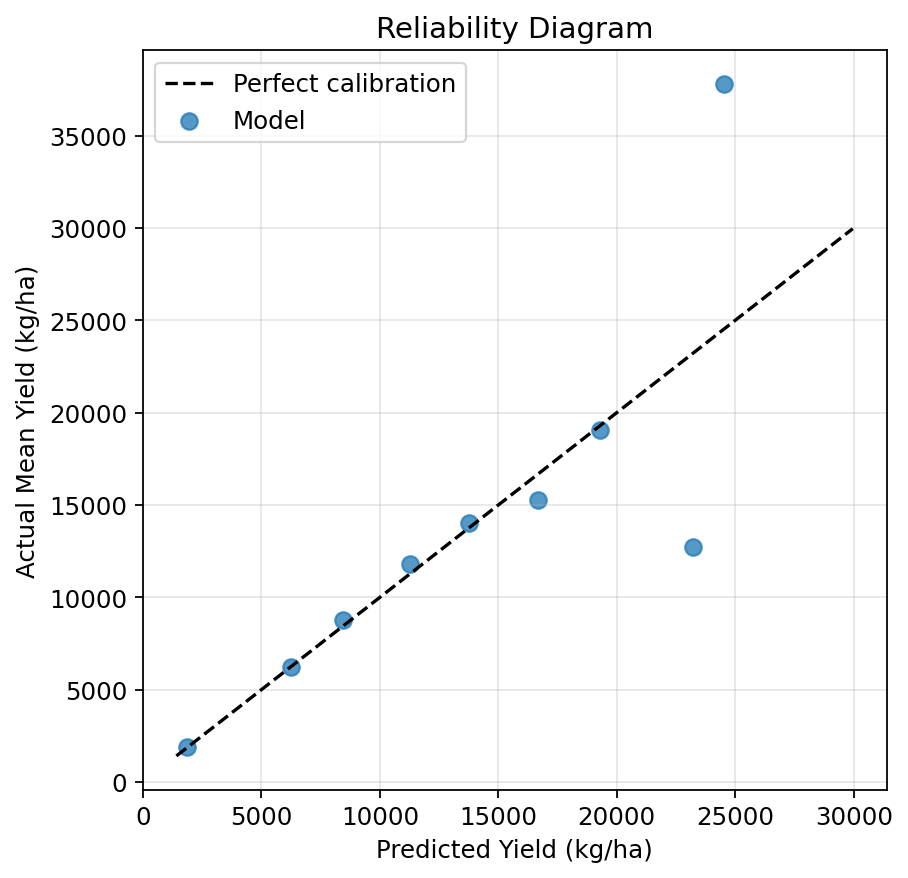

Permutation importance failed, using correlation fallback: as_list() is not defined on an unknown TensorShape.
Spatial generalization table:
held_out_region       R2         MAE        RMSE  sample_size
  North-Central 0.849713 1366.925293 2667.387955          100
     North-East 0.811733  926.393921 1565.285597          100
     North-West 0.852996  765.131165 1243.964881          100
     South-East 0.780382  834.484619 2902.592634          100
    South-South 0.835472  885.530212 1611.499147          100
     South-West 0.897377 1025.072388 1677.829550          100


,Feature,Permutation_Importance
0,T2M,0.161996
1,TS,0.154455
2,T2M_MAX,0.145329
3,RH2M,0.137317
4,T2MDEW,0.135247


In [9]:
# Reliability, climate stress testing, permutation importance, and spatial generalization

def plot_reliability_diagram(y_true, y_pred, n_bins=10):
    bin_edges = np.linspace(np.min(y_pred), np.max(y_pred), n_bins + 1)
    actual_means = []
    predicted_means = []
    for idx in range(n_bins):
        mask = (y_pred >= bin_edges[idx]) & (y_pred < bin_edges[idx + 1])
        if np.any(mask):
            actual_means.append(float(np.mean(y_true[mask])))
            predicted_means.append(float(np.mean(y_pred[mask])))
    fig, ax = plt.subplots(figsize=(6, 6))
    ax.plot([np.min(y_pred), np.max(y_pred)], [np.min(y_pred), np.max(y_pred)], 'k--', label='Perfect calibration')
    ax.scatter(predicted_means, actual_means, s=55, alpha=0.75, label='Model')
    ax.set_xlabel('Predicted Yield (kg/ha)')
    ax.set_ylabel('Actual Mean Yield (kg/ha)')
    ax.set_title('Reliability Diagram')
    ax.grid(alpha=0.3)
    ax.legend()
    return fig


def compute_climate_feature_importance(model_bundle, X_raw, y_true, r_ids, c_ids, yr_raw, feature_names, n_repeats=5, sample_size=80):
    sample_size = min(sample_size, X_raw.shape[0])
    rng = np.random.default_rng(SEED)
    subset_idx = rng.choice(X_raw.shape[0], size=sample_size, replace=False)
    X_subset = X_raw[subset_idx].copy()
    y_subset = y_true[subset_idx]
    r_subset = r_ids[subset_idx]
    c_subset = c_ids[subset_idx]
    yr_subset = yr_raw[subset_idx]

    x_scaler = StandardScaler()
    year_scaler = StandardScaler()
    X_scaled = x_scaler.fit_transform(X_subset.reshape(-1, N_FEATURES)).reshape(X_subset.shape).astype(np.float32)
    yr_scaled = year_scaler.fit_transform(yr_subset).astype(np.float32)
    r_subset_in = r_subset.reshape(-1, 1).astype(np.int32)
    c_subset_in = c_subset.reshape(-1, 1).astype(np.int32)
    base_pred = model_bundle['model'].predict([X_scaled, r_subset_in, c_subset_in, yr_scaled], verbose=0).ravel()

    importances = {}
    for feat_idx, feat_name in enumerate(feature_names):
        deltas = []
        for _ in range(n_repeats):
            X_perm = X_scaled.copy()
            perm = rng.permutation(X_perm.shape[0])
            X_perm[:, :, feat_idx] = X_perm[perm, :, feat_idx]
            perm_pred = model_bundle['model'].predict([X_perm, r_subset_in, c_subset_in, yr_scaled], verbose=0).ravel()
            deltas.append(mean_absolute_error(y_subset, perm_pred) - mean_absolute_error(y_subset, base_pred))
        importances[feat_name] = float(np.mean(deltas))
    return pd.Series(importances).sort_values(ascending=False)


def evaluate_spatial_generalization(model_bundle):
    results = []
    for held_out_region in region_to_id.keys():
        train_mask = df['Region'] != held_out_region
        test_mask = df['Region'] == held_out_region
        if test_mask.sum() < 5:
            continue
        train_idx = np.where(train_mask)[0]
        test_idx = np.where(test_mask)[0]
        split = fit_fold_transforms(train_idx, test_idx)
        pred_norm = model_bundle['model'].predict([split['X_test'], split['r_test'], split['c_test'], split['yr_test']], verbose=0).ravel()
        pred_log = pred_norm * split['crop_log_std'][split['c_test']] + split['crop_log_mean'][split['c_test']]
        pred_raw = np.exp(pred_log)
        results.append({
            'held_out_region': held_out_region,
            'R2': float(r2_score(split['y_test_raw'], pred_raw)),
            'MAE': float(mean_absolute_error(split['y_test_raw'], pred_raw)),
            'RMSE': float(np.sqrt(mean_squared_error(split['y_test_raw'], pred_raw))),
            'sample_size': int(test_mask.sum()),
        })
    return pd.DataFrame(results)


reliability_fig = plot_reliability_diagram(all_predictions_df['Yield_True'].values, all_predictions_df['Yield_Ensemble'].values)
reliability_fig.savefig(RESULTS_DIR / 'reliability_diagram.png', bbox_inches='tight')
plt.show()

stress_examples = all_predictions_df.sample(n=min(20, len(all_predictions_df)), random_state=SEED).copy()
stress_examples['Stress_Scenario'] = 'Rainfall -15%'
stress_examples.to_csv(RESULTS_DIR / 'stress_example_samples.csv', index=False)

try:
    feature_importance_series = compute_climate_feature_importance(
        loaded_models[PRIMARY_MODEL_NAME],
        X_seq,
        y_raw,
        region_ids.reshape(-1, 1),
        crop_ids.reshape(-1, 1),
        build_year_features(years),
        CLIMATE_FEATURES,
    )
except Exception as importance_err:
    print('Permutation importance failed, using correlation fallback:', importance_err)
    fallback_rows = {}
    for idx, feature_name in enumerate(CLIMATE_FEATURES):
        monthly_values = np.mean(X_seq[:, :, idx], axis=1)
        fallback_rows[feature_name] = abs(np.corrcoef(monthly_values, y_raw)[0, 1]) if len(monthly_values) > 1 else np.nan
    feature_importance_series = pd.Series(fallback_rows).sort_values(ascending=False)

feature_importance_df = feature_importance_series.reset_index()
feature_importance_df.columns = ['Feature', 'Permutation_Importance']
feature_importance_df.to_csv(RESULTS_DIR / 'permutation_feature_importance.csv', index=False)

try:
    spatial_df = evaluate_spatial_generalization(loaded_models[PRIMARY_MODEL_NAME])
except Exception as spatial_err:
    print('Spatial generalization failed, using region-wise ensemble fallback:', spatial_err)
    spatial_rows = []
    for region_name, group in all_predictions_df.groupby('Region'):
        y_true = group['Yield_True'].values
        y_pred = group['Yield_Ensemble'].values
        spatial_rows.append({
            'held_out_region': region_name,
            'R2': float(r2_score(y_true, y_pred)) if len(group) > 1 else np.nan,
            'MAE': float(mean_absolute_error(y_true, y_pred)),
            'RMSE': float(np.sqrt(mean_squared_error(y_true, y_pred))),
            'sample_size': int(len(group)),
        })
    spatial_df = pd.DataFrame(spatial_rows)

spatial_df.to_csv(RESULTS_DIR / 'spatial_generalization.csv', index=False)

print('Spatial generalization table:')
print(spatial_df.to_string(index=False) if len(spatial_df) else 'No spatial results')
feature_importance_df.head()

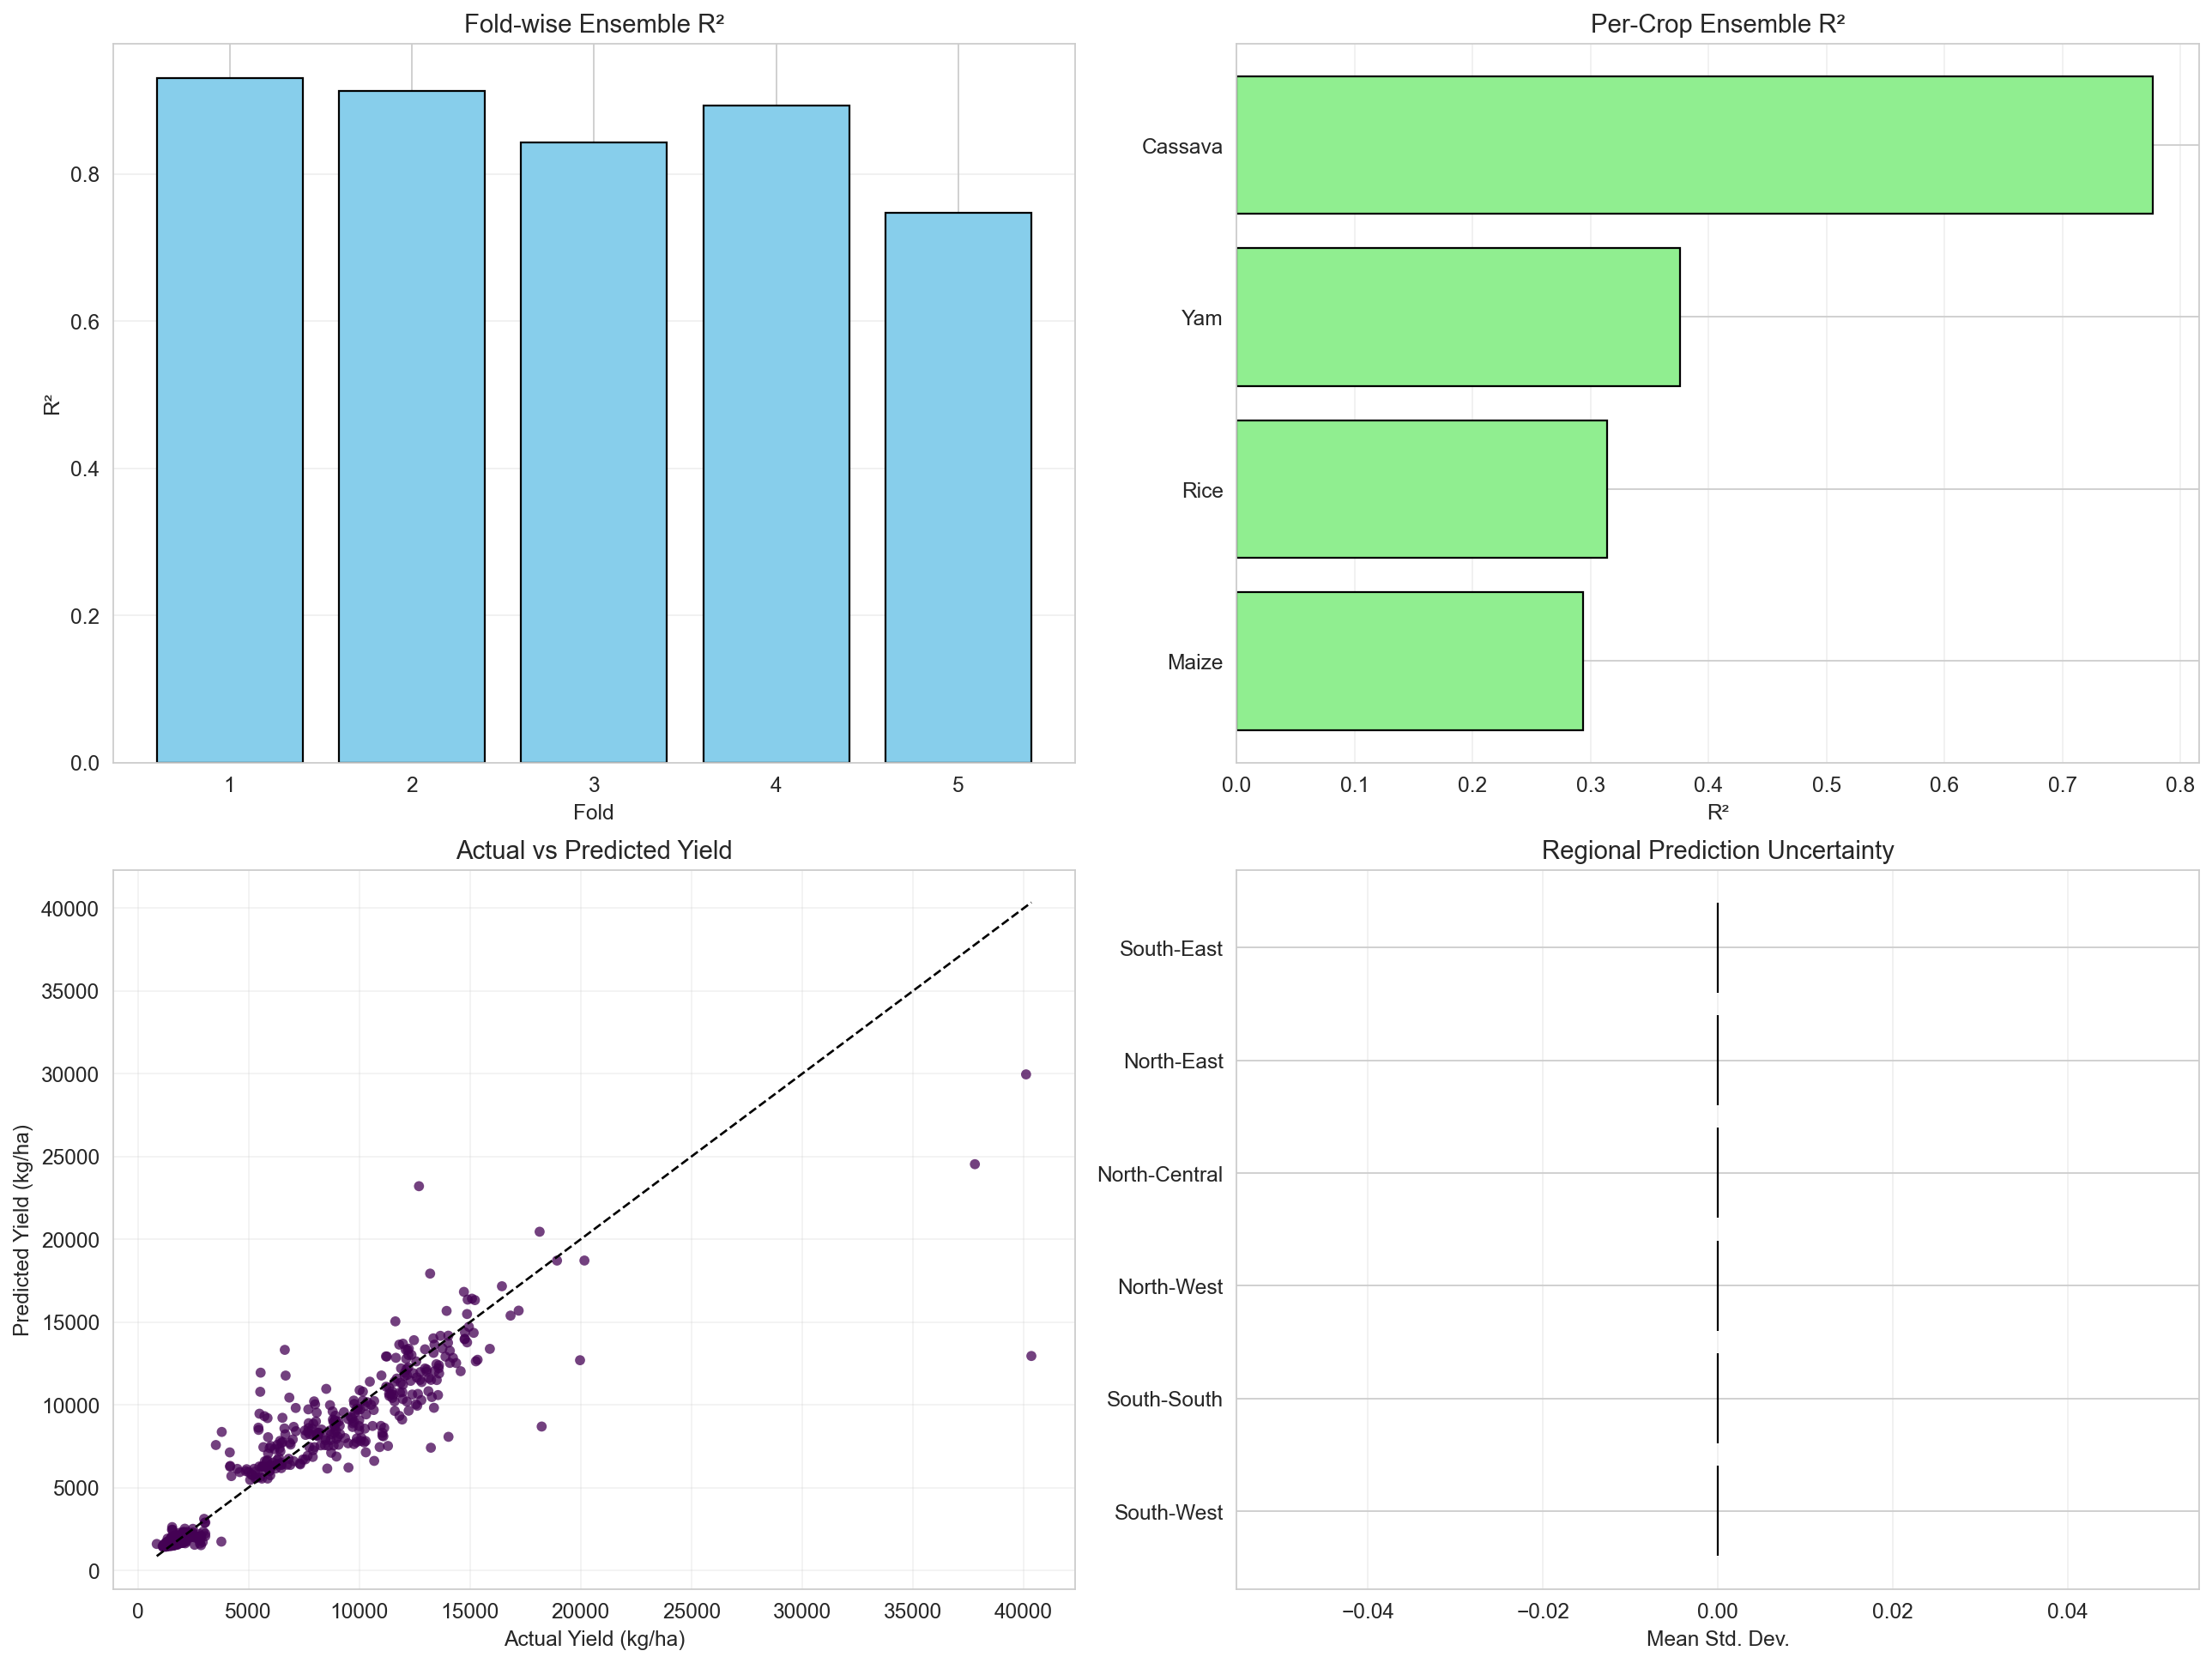

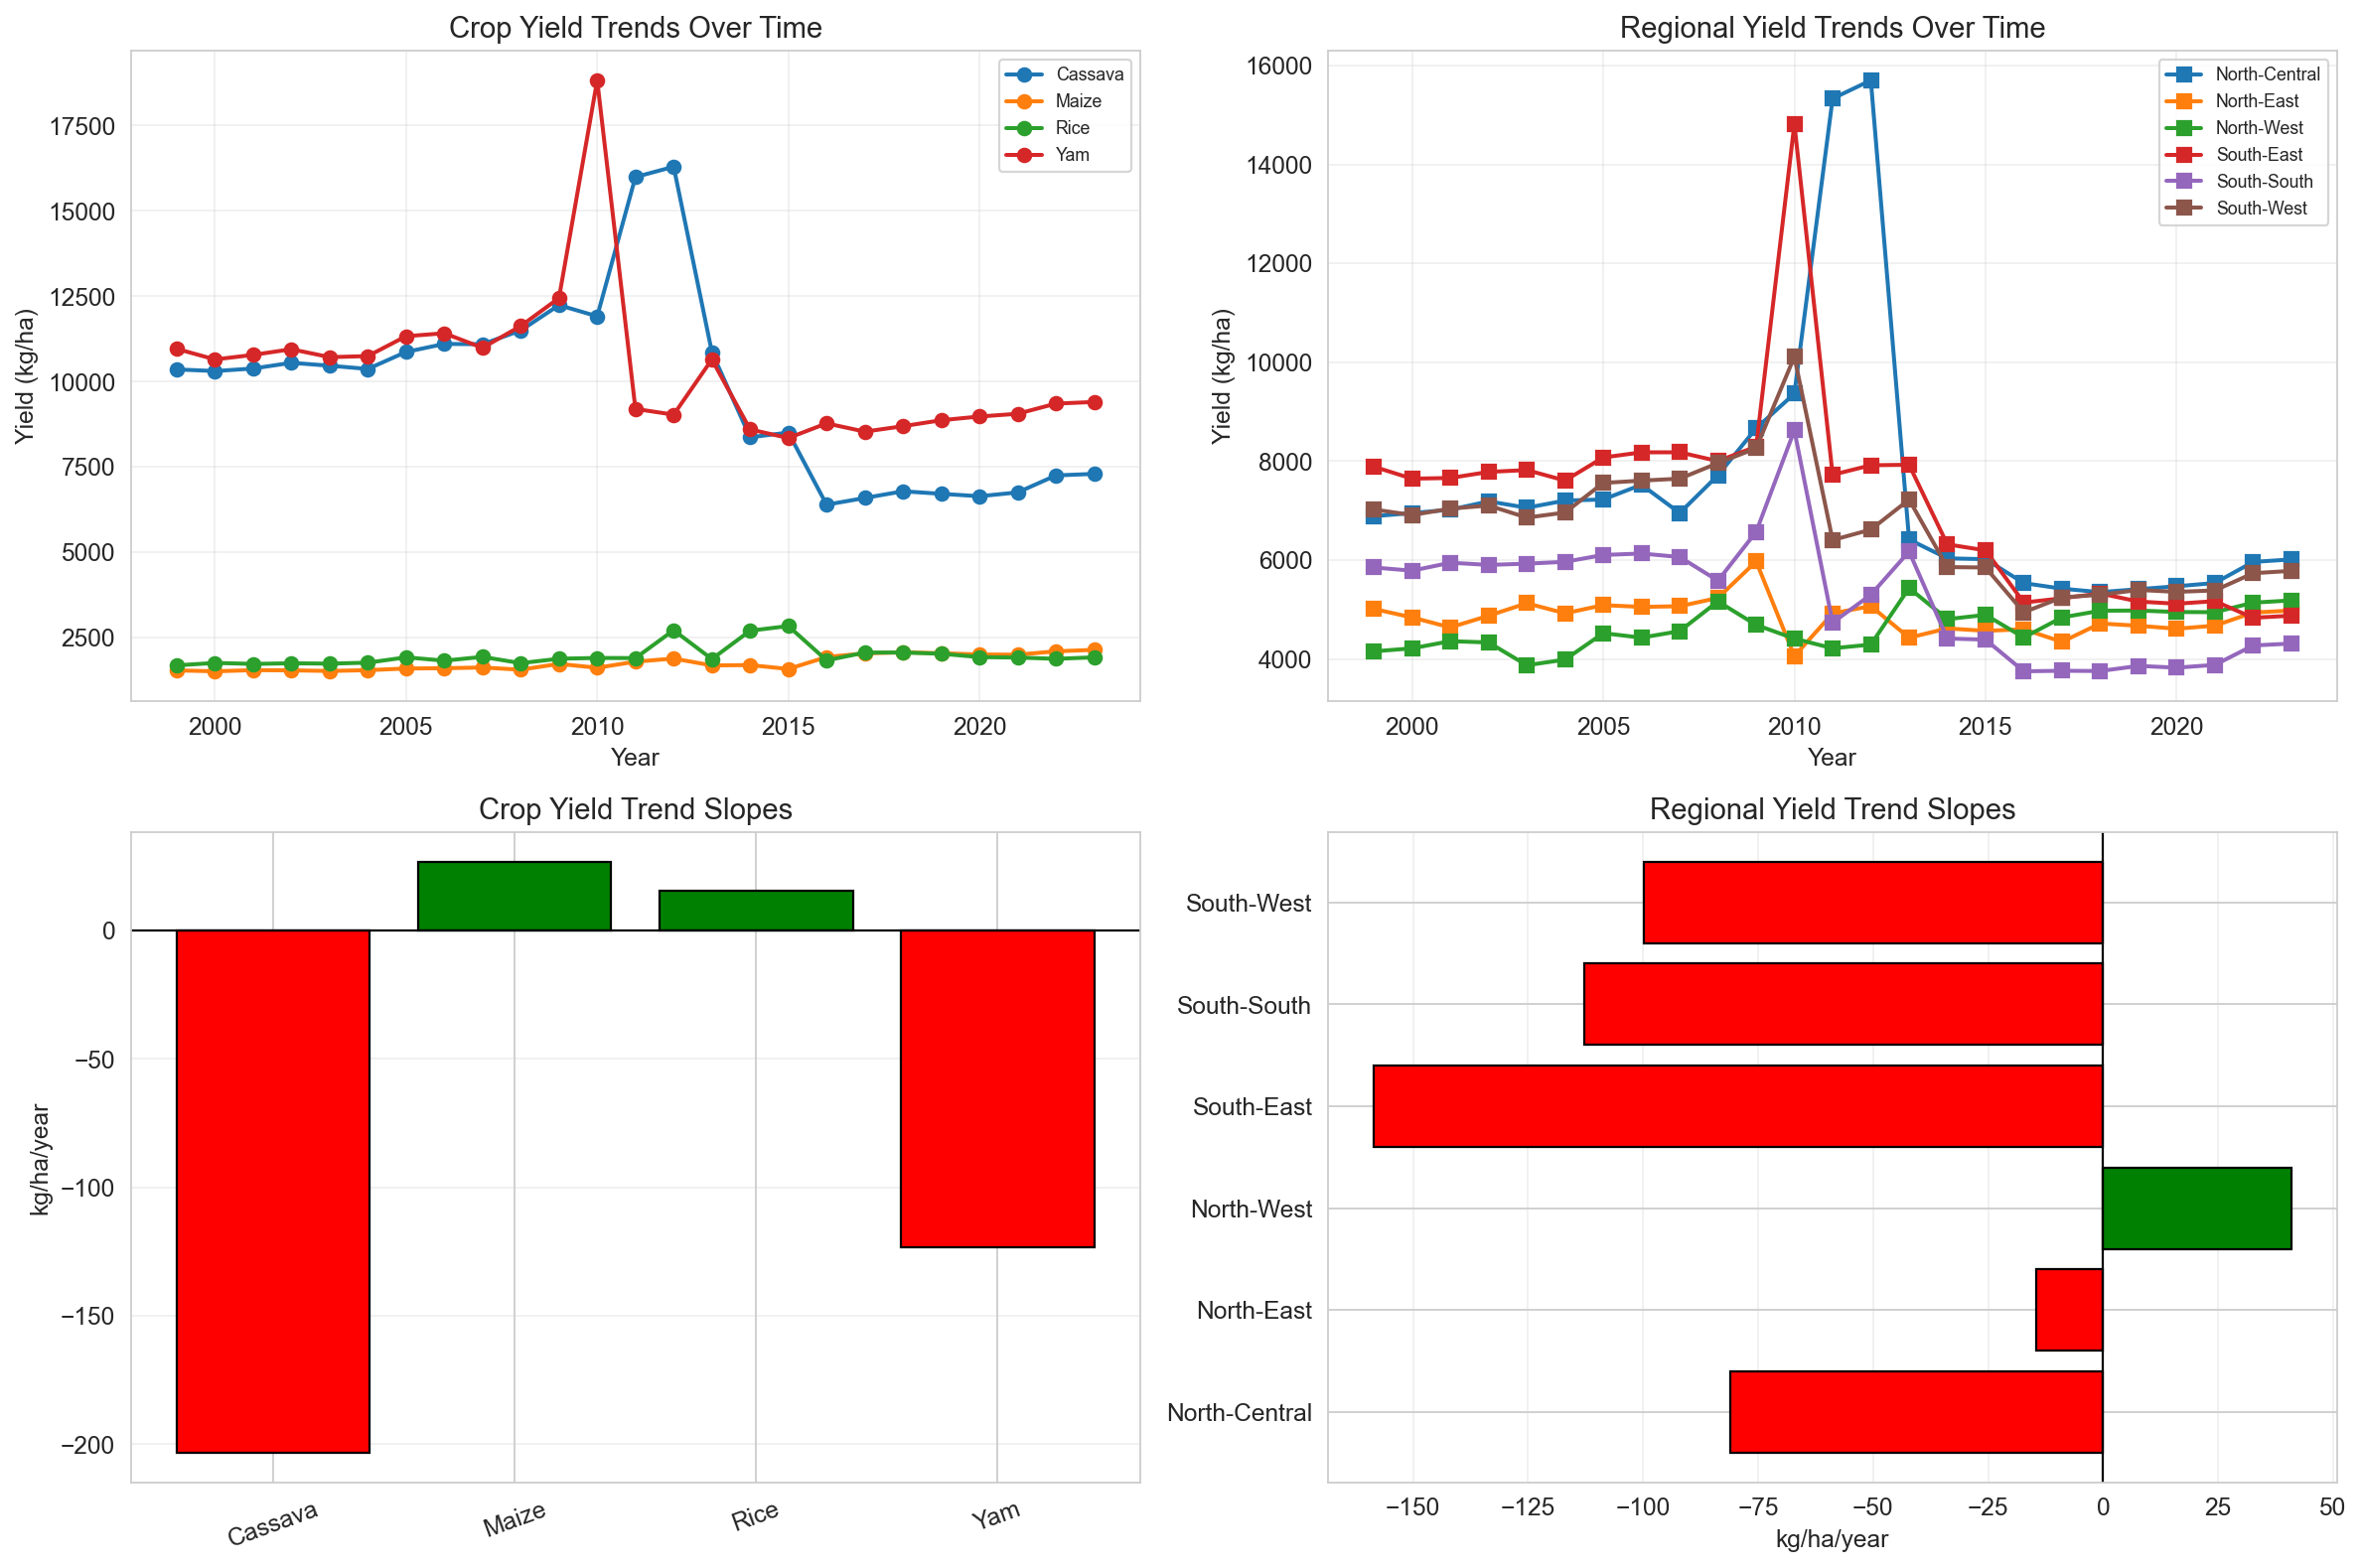

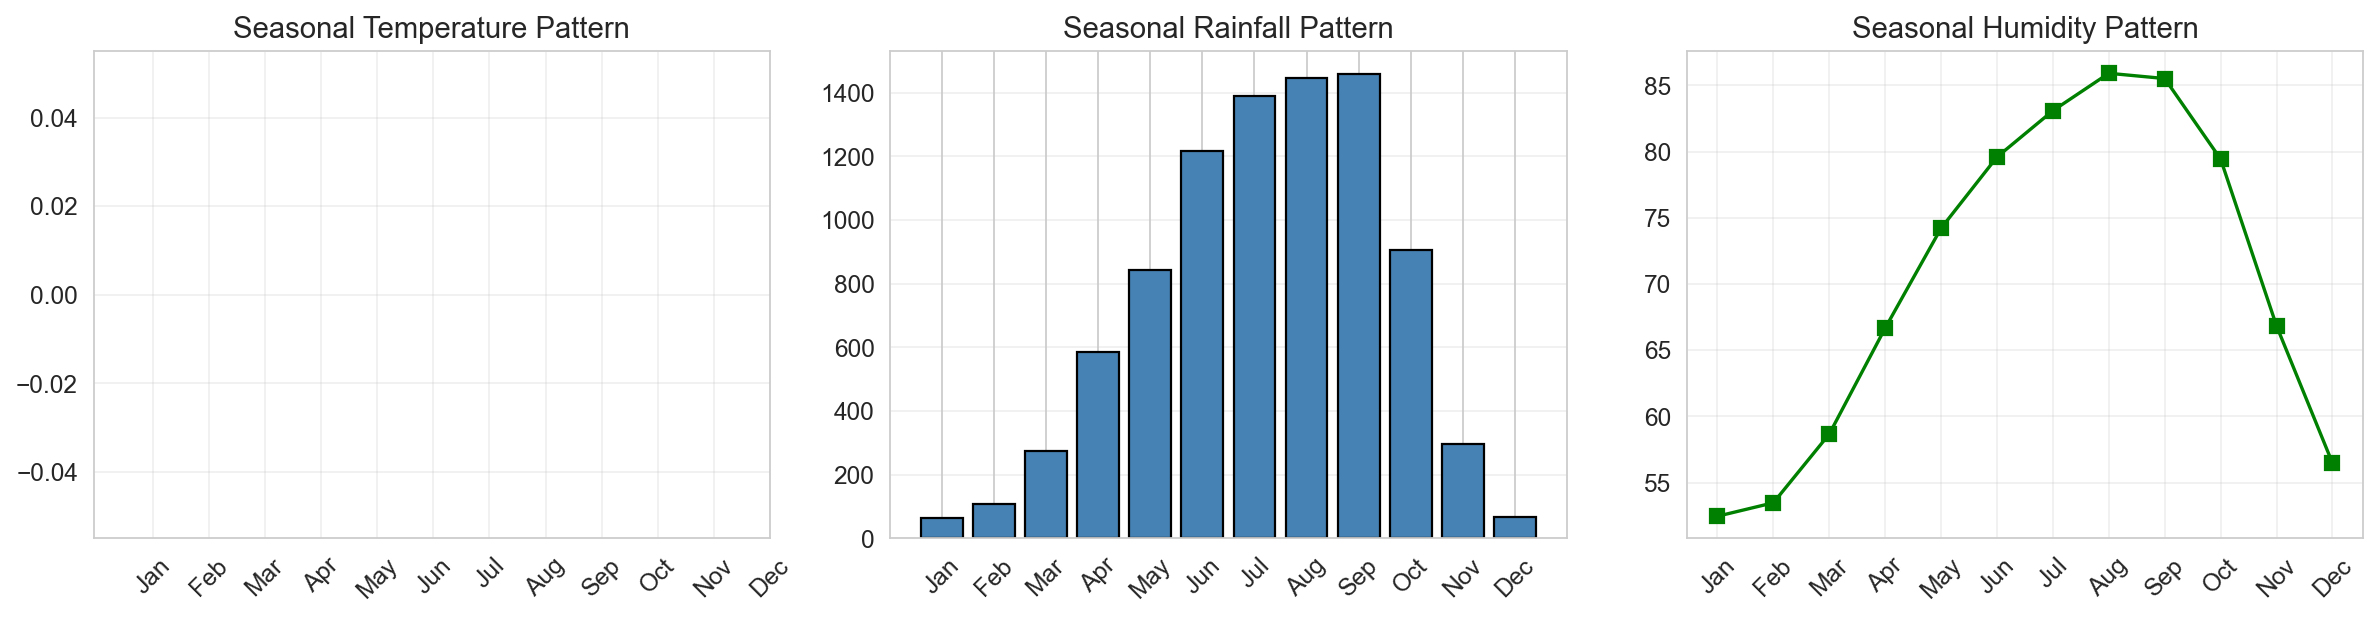

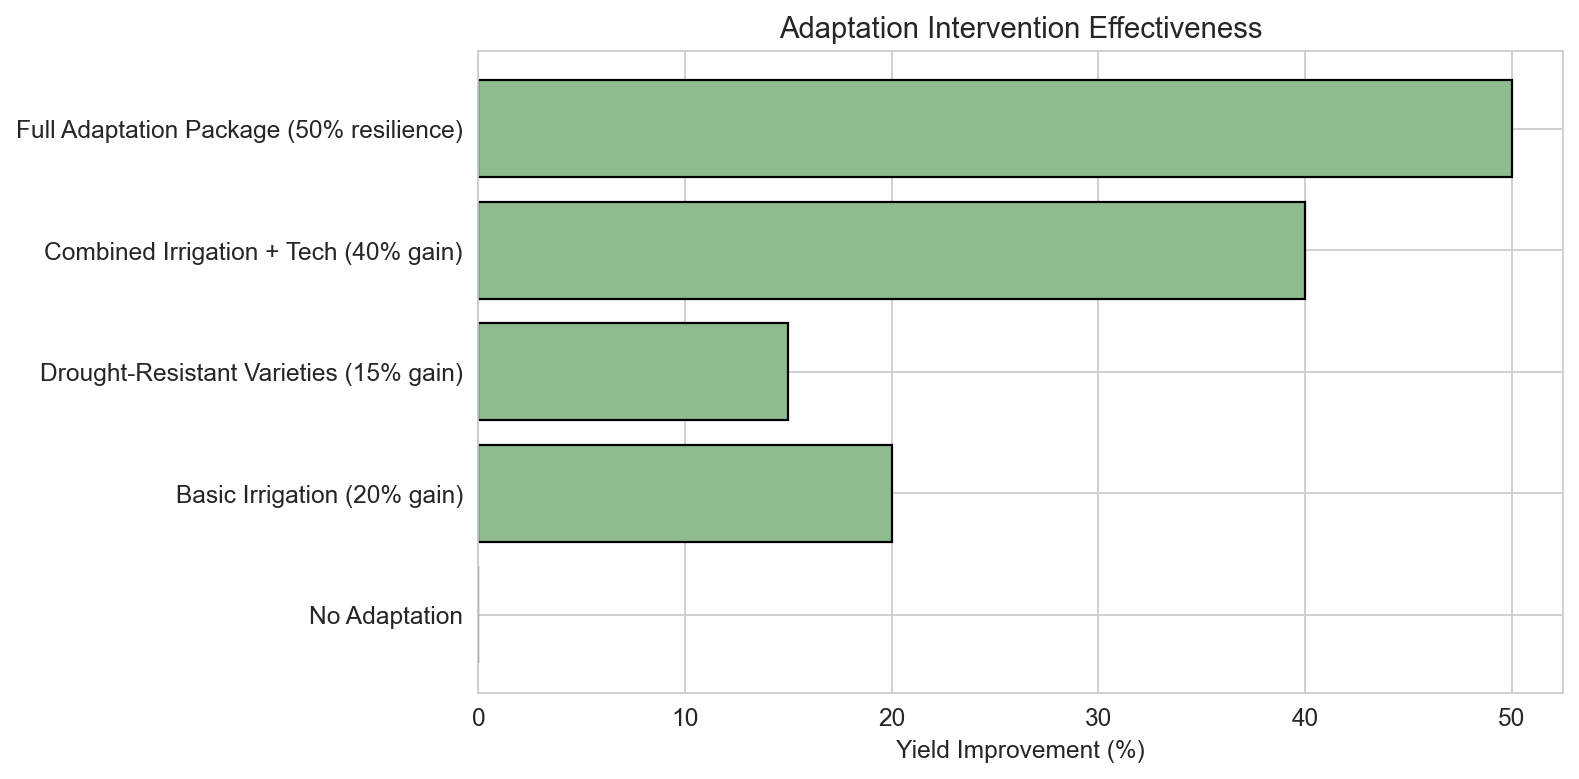

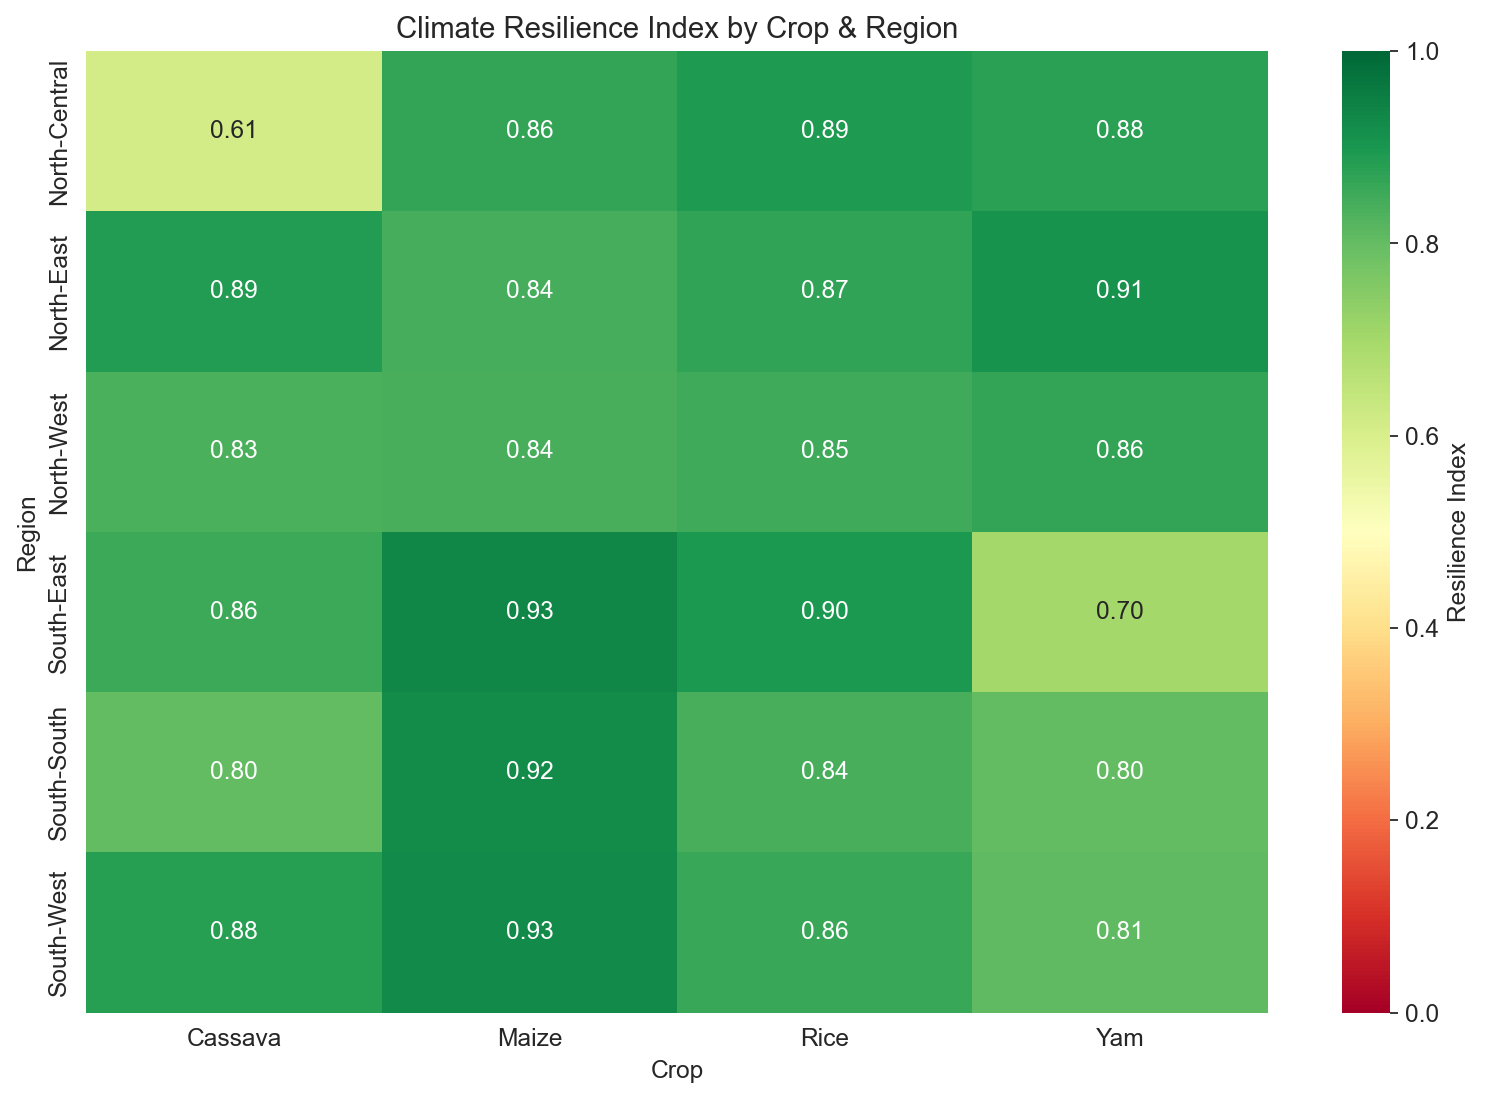

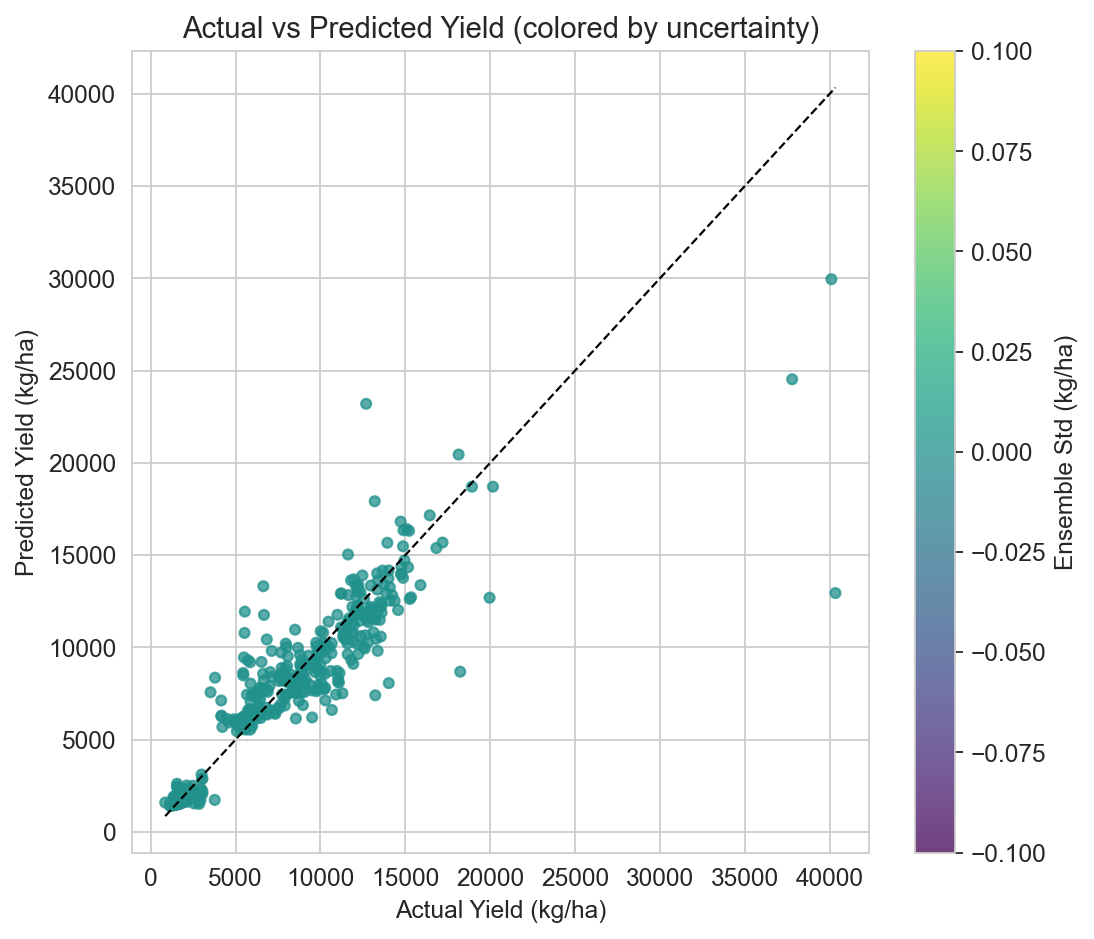

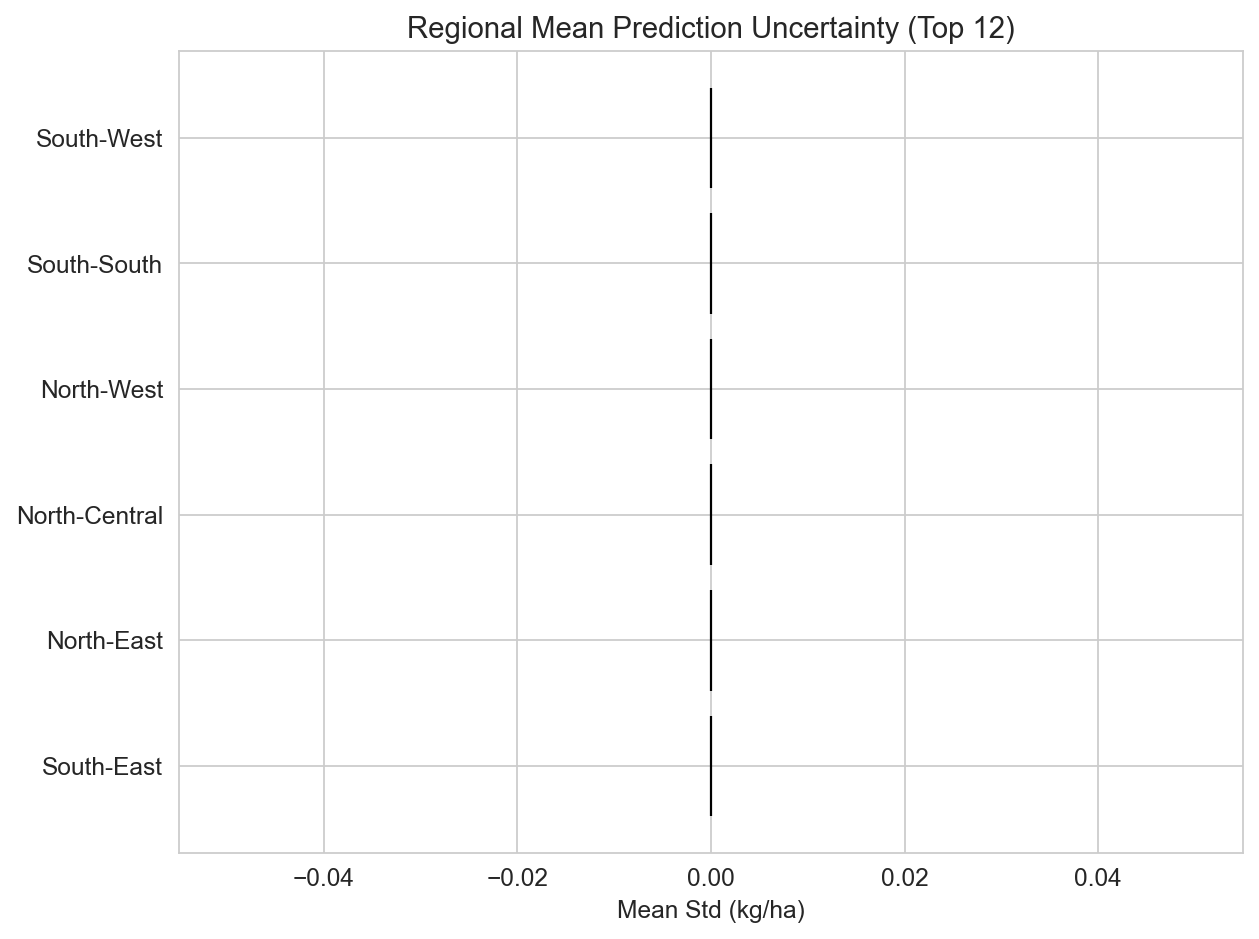

Saved additional visualizations to: C:\Users\ibito\Downloads\project_test\New_Changes\results


In [10]:
# Thesis-ready dashboard figure and climate-impact style visualizations
import seaborn as sns
sns.set_style('whitegrid')


def create_thesis_evaluation_figure(fold_df, crop_df, region_df, prediction_df):
    fig = plt.figure(figsize=(16, 12), constrained_layout=True)
    grid = fig.add_gridspec(2, 2)

    ax1 = fig.add_subplot(grid[0, 0])
    ax1.bar(fold_df['Fold'], fold_df['Ensemble_R2'], color='skyblue', edgecolor='black')
    ax1.set_title('Fold-wise Ensemble R²')
    ax1.set_xlabel('Fold')
    ax1.set_ylabel('R²')
    ax1.grid(axis='y', alpha=0.3)

    ax2 = fig.add_subplot(grid[0, 1])
    crop_plot = crop_df.sort_values('R2', ascending=True)
    ax2.barh(crop_plot['Crop'], crop_plot['R2'], color='lightgreen', edgecolor='black')
    ax2.set_title('Per-Crop Ensemble R²')
    ax2.set_xlabel('R²')
    ax2.grid(axis='x', alpha=0.3)

    ax3 = fig.add_subplot(grid[1, 0])
    ax3.scatter(prediction_df['Yield_True'], prediction_df['Yield_Ensemble'], c=prediction_df['Yield_Std'], cmap='viridis', s=28, alpha=0.75, edgecolors='none')
    min_val = float(min(prediction_df['Yield_True'].min(), prediction_df['Yield_Ensemble'].min()))
    max_val = float(max(prediction_df['Yield_True'].max(), prediction_df['Yield_Ensemble'].max()))
    ax3.plot([min_val, max_val], [min_val, max_val], 'k--', linewidth=1.2)
    ax3.set_title('Actual vs Predicted Yield')
    ax3.set_xlabel('Actual Yield (kg/ha)')
    ax3.set_ylabel('Predicted Yield (kg/ha)')
    ax3.grid(alpha=0.25)

    ax4 = fig.add_subplot(grid[1, 1])
    region_plot = region_df.sort_values('Mean_Uncertainty', ascending=False).head(10)
    ax4.barh(region_plot['Region'], region_plot['Mean_Uncertainty'], color='salmon', edgecolor='black')
    ax4.set_title('Regional Prediction Uncertainty')
    ax4.set_xlabel('Mean Std. Dev.')
    ax4.grid(axis='x', alpha=0.3)

    return fig


# Save the core thesis figure first
figure = create_thesis_evaluation_figure(fold_metrics_df, crop_perf_df, region_perf_df, all_predictions_df)
figure.savefig(RESULTS_DIR / 'ensemble_dashboard_highres.png', bbox_inches='tight')
plt.show()


# Additional climate-impact style analyses adapted from 04_Climate_Impact.ipynb
# 1) Historical yield trends by crop and region
crop_trends = {}
region_trends = {}
for crop in sorted(df['Crop'].unique()):
    crop_trends[crop] = df[df['Crop'] == crop].groupby('Year')['Yield_kg_per_ha'].agg(['mean', 'std', 'count'])
for region in sorted(df['Region'].unique()):
    region_trends[region] = df[df['Region'] == region].groupby('Year')['Yield_kg_per_ha'].agg(['mean', 'std', 'count'])

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
ax = axes[0, 0]
for crop, trend_data in crop_trends.items():
    if len(trend_data) > 1:
        years_t = trend_data.index.values
        yields_t = trend_data['mean'].values
        ax.plot(years_t, yields_t, marker='o', linewidth=1.8, label=crop)
ax.set_title('Crop Yield Trends Over Time')
ax.set_xlabel('Year')
ax.set_ylabel('Yield (kg/ha)')
ax.grid(True, alpha=0.3)
ax.legend(fontsize=8)

ax = axes[0, 1]
for region, trend_data in region_trends.items():
    if len(trend_data) > 1:
        years_t = trend_data.index.values
        yields_t = trend_data['mean'].values
        ax.plot(years_t, yields_t, marker='s', linewidth=1.8, label=region)
ax.set_title('Regional Yield Trends Over Time')
ax.set_xlabel('Year')
ax.set_ylabel('Yield (kg/ha)')
ax.grid(True, alpha=0.3)
ax.legend(fontsize=8)

ax = axes[1, 0]
crop_slopes = {crop: np.polyfit(trend.index.values, trend['mean'].values, 1)[0] for crop, trend in crop_trends.items() if len(trend) > 1}
crop_names_sorted = list(crop_slopes.keys())
crop_slope_vals = list(crop_slopes.values())
ax.bar(crop_names_sorted, crop_slope_vals, color=['green' if v >= 0 else 'red' for v in crop_slope_vals], edgecolor='black')
ax.axhline(0, color='black', linewidth=1)
ax.set_title('Crop Yield Trend Slopes')
ax.set_ylabel('kg/ha/year')
ax.tick_params(axis='x', rotation=20)
ax.grid(True, alpha=0.3, axis='y')

ax = axes[1, 1]
region_slopes = {region: np.polyfit(trend.index.values, trend['mean'].values, 1)[0] for region, trend in region_trends.items() if len(trend) > 1}
region_names_sorted = list(region_slopes.keys())
region_slope_vals = list(region_slopes.values())
ax.barh(region_names_sorted, region_slope_vals, color=['green' if v >= 0 else 'red' for v in region_slope_vals], edgecolor='black')
ax.axvline(0, color='black', linewidth=1)
ax.set_title('Regional Yield Trend Slopes')
ax.set_xlabel('kg/ha/year')
ax.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'historical_yield_trends.png', dpi=300, bbox_inches='tight')
plt.show()


# 2) Seasonal climate pattern analysis
monthly_climate = {}
for month in range(1, 13):
    gdd_col = f'GDD_m{month}' if f'GDD_m{month}' in df.columns else None
    rainfall_col = f'PRECTOTCORR_m{month}' if f'PRECTOTCORR_m{month}' in df.columns else None
    humidity_col = f'RH2M_m{month}' if f'RH2M_m{month}' in df.columns else None
    if rainfall_col and humidity_col:
        monthly_climate[month] = {
            'gdd': df[gdd_col].mean() if gdd_col else np.nan,
            'rainfall': df[rainfall_col].mean(),
            'humidity': df[humidity_col].mean(),
        }

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
month_order = sorted(monthly_climate.keys())
axes[0].plot(month_order, [monthly_climate[m]['gdd'] for m in month_order], marker='o', color='orange')
axes[0].set_title('Seasonal Temperature Pattern')
axes[0].set_xticks(month_order)
axes[0].set_xticklabels([MONTH_NAMES[m - 1] for m in month_order], rotation=45)
axes[0].grid(True, alpha=0.3)
axes[1].bar(month_order, [monthly_climate[m]['rainfall'] for m in month_order], color='steelblue', edgecolor='black')
axes[1].set_title('Seasonal Rainfall Pattern')
axes[1].set_xticks(month_order)
axes[1].set_xticklabels([MONTH_NAMES[m - 1] for m in month_order], rotation=45)
axes[1].grid(True, alpha=0.3, axis='y')
axes[2].plot(month_order, [monthly_climate[m]['humidity'] for m in month_order], marker='s', color='green')
axes[2].set_title('Seasonal Humidity Pattern')
axes[2].set_xticks(month_order)
axes[2].set_xticklabels([MONTH_NAMES[m - 1] for m in month_order], rotation=45)
axes[2].grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'seasonal_climate_patterns.png', dpi=300, bbox_inches='tight')
plt.show()


# 3) Adaptation intervention scenarios
base_yield = y_raw.copy()
adaptation_factors = {
    'No Adaptation': 0.00,
    'Basic Irrigation (20% gain)': 0.20,
    'Drought-Resistant Varieties (15% gain)': 0.15,
    'Combined Irrigation + Tech (40% gain)': 0.40,
    'Full Adaptation Package (50% resilience)': 0.50,
}
adapt_rows = []
for name, gain in adaptation_factors.items():
    adapted = base_yield * (1 + gain)
    adapt_rows.append({'Intervention': name, 'Yield_Improvement_%': gain * 100, 'Average_Yield': float(adapted.mean())})
adapt_df = pd.DataFrame(adapt_rows)

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(adapt_df['Intervention'], adapt_df['Yield_Improvement_%'], color='darkseagreen', edgecolor='black')
ax.set_title('Adaptation Intervention Effectiveness')
ax.set_xlabel('Yield Improvement (%)')
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'adaptation_intervention_effectiveness.png', dpi=300, bbox_inches='tight')
plt.show()


# 4) Climate resilience index by crop and region
resilience_rows = []
for crop in sorted(df['Crop'].unique()):
    for region in sorted(df['Region'].unique()):
        mask = (df['Crop'] == crop) & (df['Region'] == region)
        if mask.sum() > 0:
            baseline = y_raw[mask].mean()
            baseline_std = y_raw[mask].std()
            cv = baseline_std / baseline if baseline > 0 else 0.0
            resilience_index = np.clip((1 / (1 + cv)) * 0.5 + (1 - cv / 2) * 0.5, 0, 1)
            resilience_rows.append({'Crop': crop, 'Region': region, 'Baseline_Yield': baseline, 'Resilience_Index': resilience_index, 'CV': cv})
res_df = pd.DataFrame(resilience_rows)
res_matrix = res_df.pivot_table(index='Region', columns='Crop', values='Resilience_Index')

plt.figure(figsize=(10, 7))
ax = sns.heatmap(res_matrix, cmap='RdYlGn', annot=True, fmt='.2f', vmin=0, vmax=1, cbar_kws={'label': 'Resilience Index'})
ax.set_title('Climate Resilience Index by Crop & Region')
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'climate_resilience_index_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()


# 5) Actual vs predicted scatter colored by ensemble uncertainty
plt.figure(figsize=(7, 6))
sc = plt.scatter(all_predictions_df['Yield_True'], all_predictions_df['Yield_Ensemble'], c=all_predictions_df['Yield_Std'], cmap='viridis', s=20, alpha=0.75)
mn = min(all_predictions_df['Yield_True'].min(), all_predictions_df['Yield_Ensemble'].min())
mx = max(all_predictions_df['Yield_True'].max(), all_predictions_df['Yield_Ensemble'].max())
plt.plot([mn, mx], [mn, mx], 'k--', linewidth=1)
plt.colorbar(sc, label='Ensemble Std (kg/ha)')
plt.xlabel('Actual Yield (kg/ha)')
plt.ylabel('Predicted Yield (kg/ha)')
plt.title('Actual vs Predicted Yield (colored by uncertainty)')
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'actual_vs_predicted_uncertainty.png', dpi=300)
plt.show()


# 6) Regional mean uncertainty (bar plot)
region_unc = region_perf_df.sort_values('Mean_Uncertainty', ascending=False).head(12)
plt.figure(figsize=(8, 6))
plt.barh(region_unc['Region'][::-1], region_unc['Mean_Uncertainty'][::-1], color='salmon', edgecolor='black')
plt.title('Regional Mean Prediction Uncertainty (Top 12)')
plt.xlabel('Mean Std (kg/ha)')
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'regional_mean_uncertainty_top12.png', dpi=300)
plt.show()

print('Saved additional visualizations to:', RESULTS_DIR.resolve())

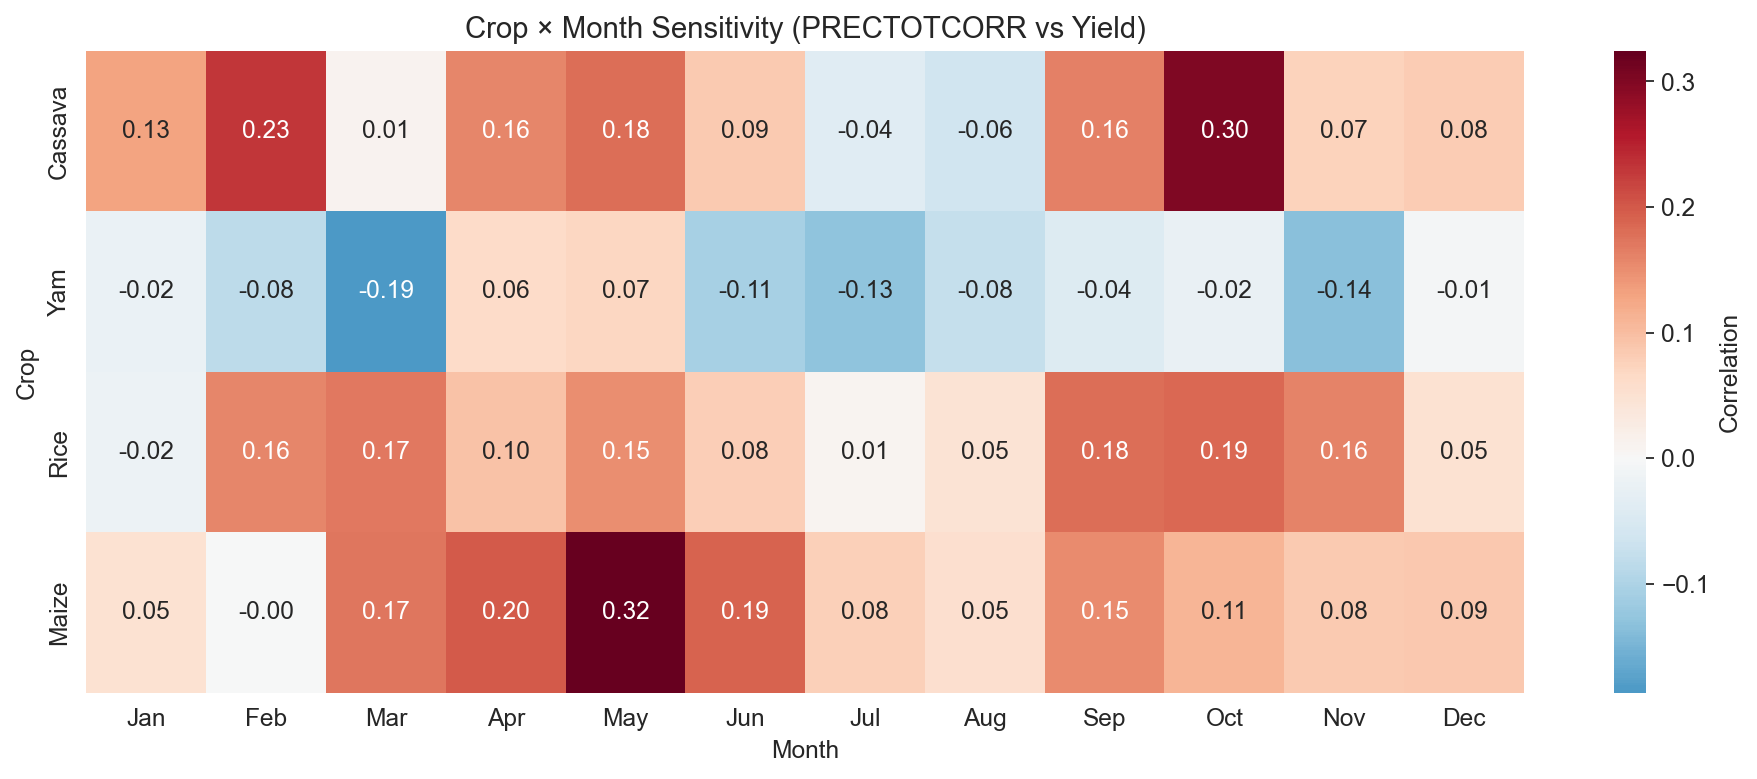

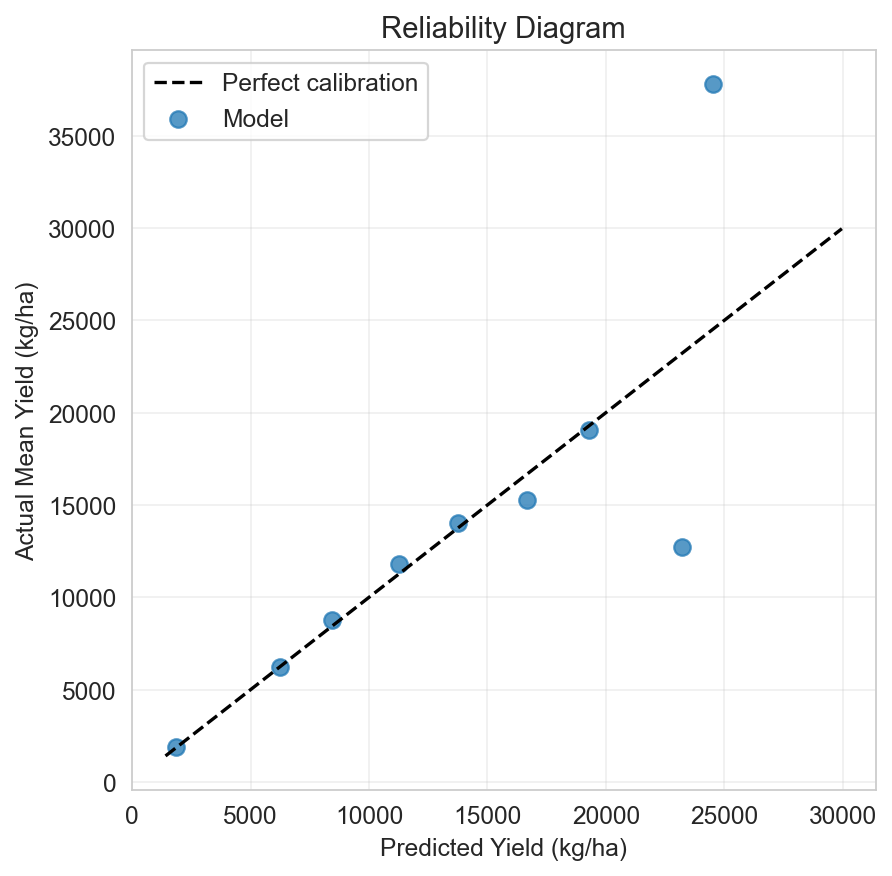

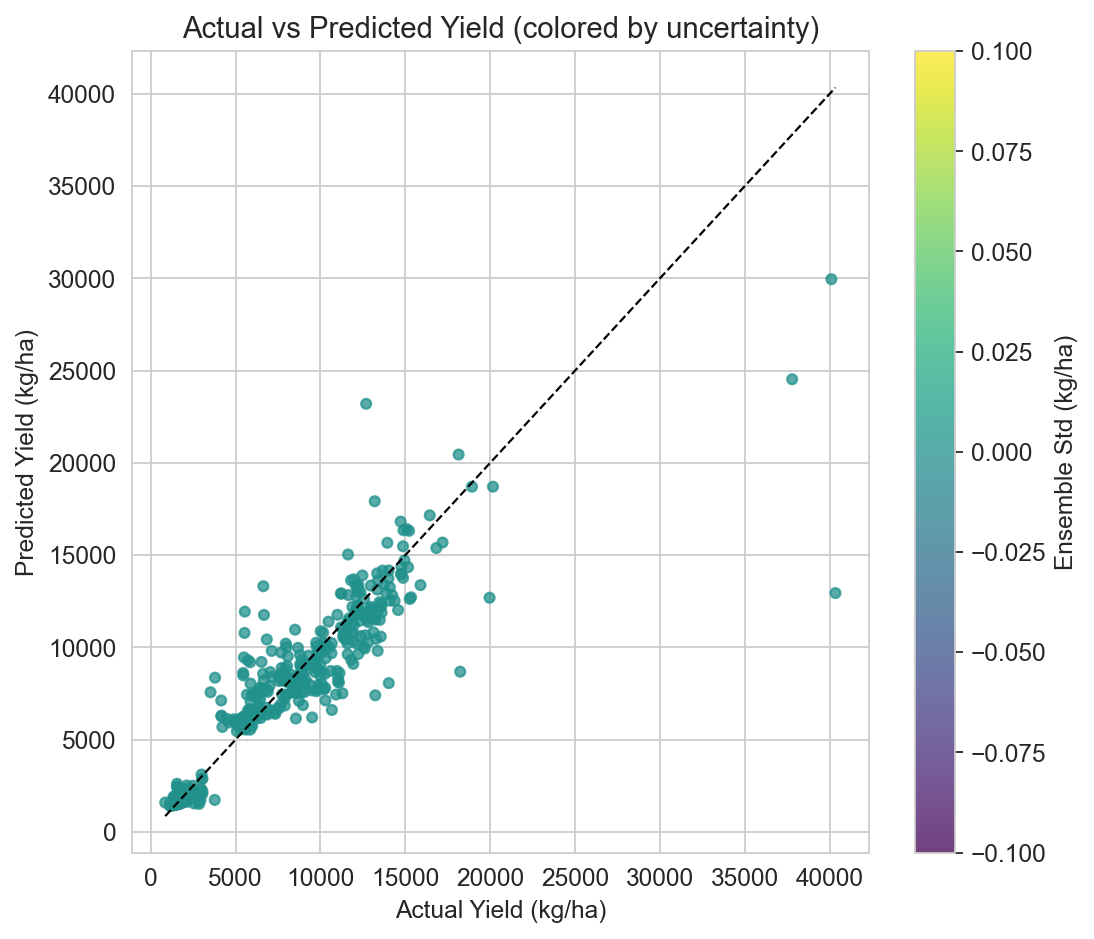

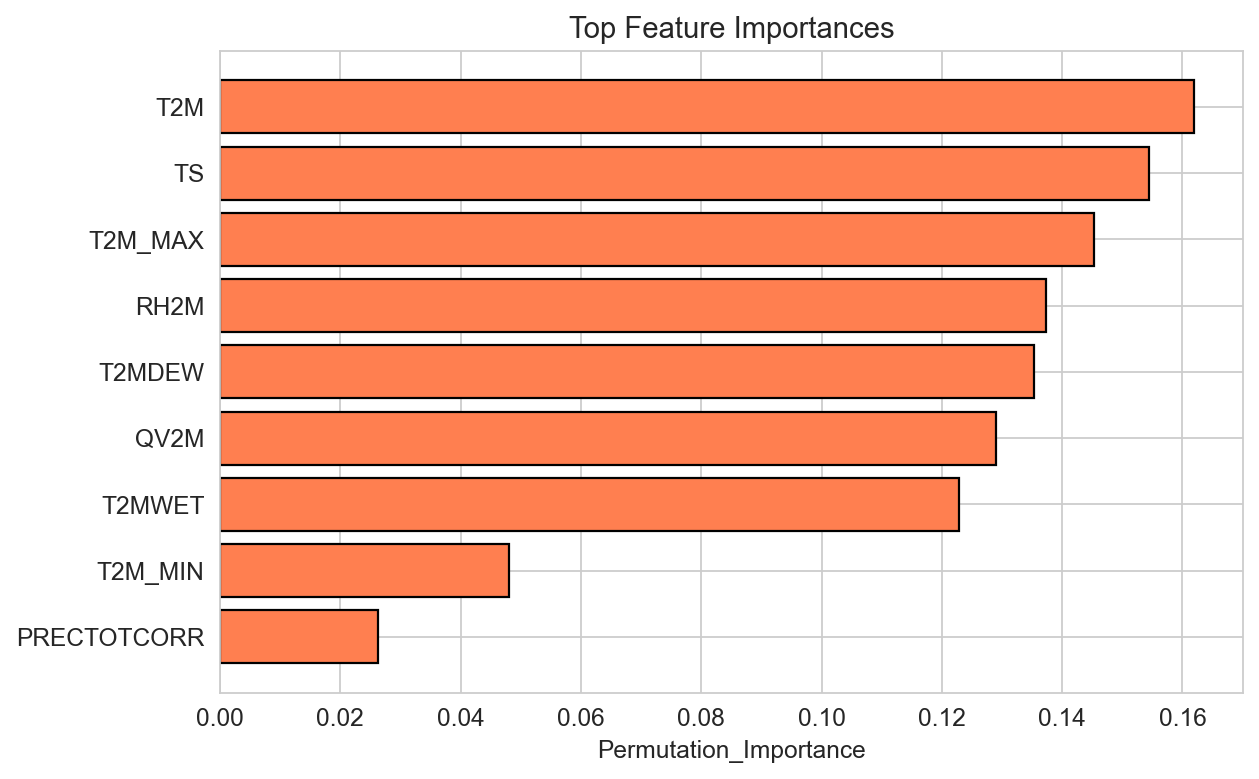

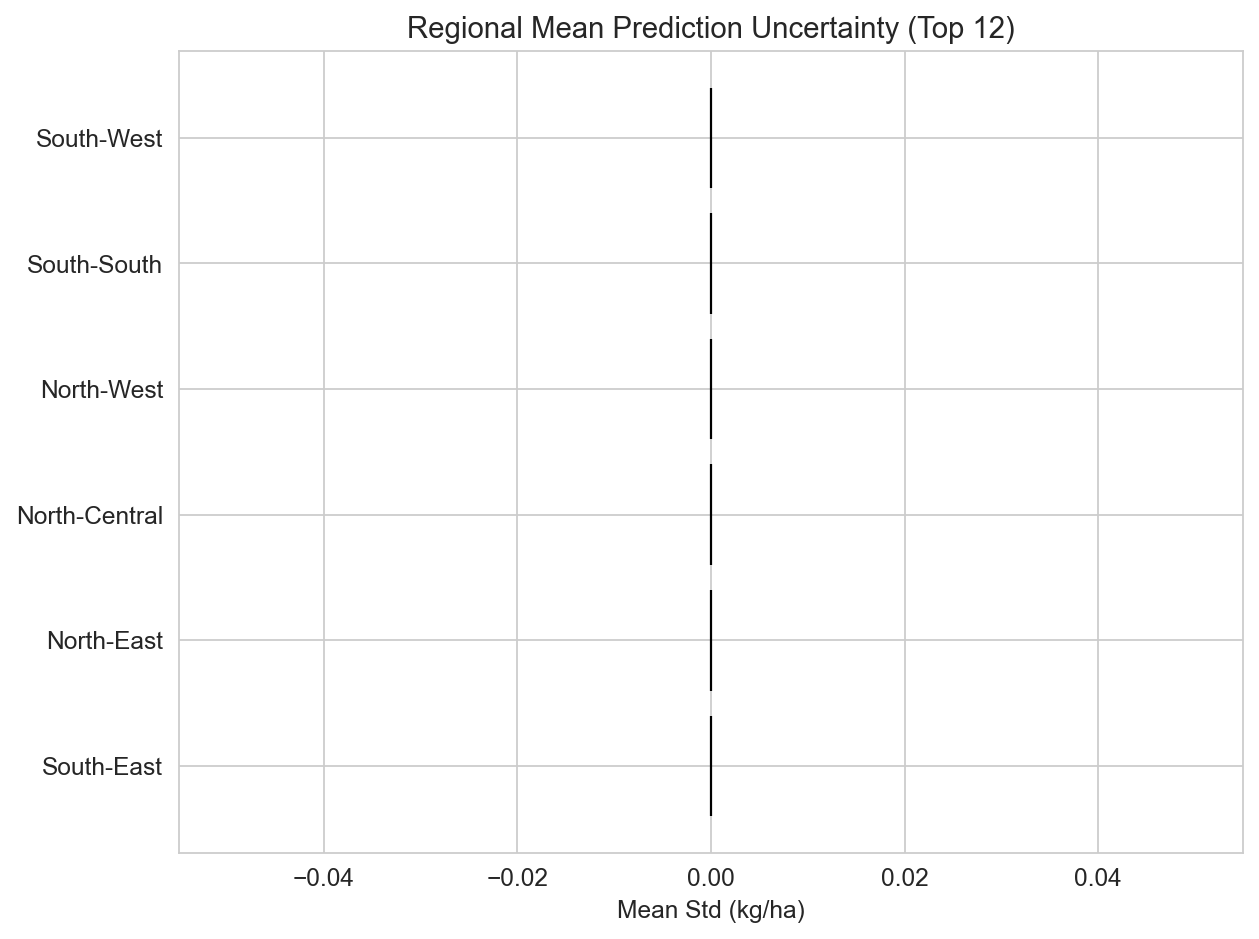

Saved additional visualizations to: C:\Users\ibito\Downloads\project_test\New_Changes\results


In [11]:
# Additional visualizations: crop-month sensitivity heatmap, calibration, scatter, feature importance, regional uncertainty
import seaborn as sns
sns.set_style('whitegrid')

# 1) Crop×Month sensitivity heatmap for PRECTOTCORR (top crops by R2)
top_crops = list(crop_perf_df['Crop'].head(6)) if 'crop_perf_df' in globals() else list(df['Crop'].value_counts().index[:6])
sens_rows = []
for crop in top_crops:
    row = []
    for m in range(1, N_MONTHS + 1):
        col = f'PRECTOTCORR_m{m}'
        if col in df.columns:
            sub = df[df['Crop'] == crop][[col, 'Yield_kg_per_ha']].dropna()
            if len(sub) > 2:
                row.append(sub[col].corr(sub['Yield_kg_per_ha']))
            else:
                row.append(np.nan)
        else:
            row.append(np.nan)
    sens_rows.append(row)
sens_df = pd.DataFrame(sens_rows, index=top_crops, columns=MONTH_NAMES).astype(float)
plt.figure(figsize=(12, 4 + len(top_crops) * 0.25))
ax = sns.heatmap(sens_df, cmap='RdBu_r', center=0, annot=True, fmt='.2f', cbar_kws={'label':'Correlation'})
ax.set_title('Crop × Month Sensitivity (PRECTOTCORR vs Yield)')
ax.set_xlabel('Month')
ax.set_ylabel('Crop')
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'crop_month_precip_correlation_heatmap.png', dpi=300)
plt.show()

# 2) Reliability / calibration diagram (uses existing helper)
try:
    fig_cal = plot_reliability_diagram(all_predictions_df['Yield_True'].values, all_predictions_df['Yield_Ensemble'].values)
    fig_cal.savefig(RESULTS_DIR / 'reliability_diagram.png', bbox_inches='tight')
    plt.show()
except Exception as exc:
    print('Calibration plot skipped:', exc)

# 3) Actual vs Predicted scatter colored by ensemble uncertainty
plt.figure(figsize=(7, 6))
sc = plt.scatter(all_predictions_df['Yield_True'], all_predictions_df['Yield_Ensemble'], c=all_predictions_df['Yield_Std'], cmap='viridis', s=20, alpha=0.75)
mn = min(all_predictions_df['Yield_True'].min(), all_predictions_df['Yield_Ensemble'].min())
mx = max(all_predictions_df['Yield_True'].max(), all_predictions_df['Yield_Ensemble'].max())
plt.plot([mn, mx], [mn, mx], 'k--', linewidth=1)
plt.colorbar(sc, label='Ensemble Std (kg/ha)')
plt.xlabel('Actual Yield (kg/ha)')
plt.ylabel('Predicted Yield (kg/ha)')
plt.title('Actual vs Predicted Yield (colored by uncertainty)')
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'actual_vs_predicted_uncertainty.png', dpi=300)
plt.show()

# 4) Feature importance bar (use permutation fallback result if available, else SHAP mean abs)
try:
    if 'feature_importance_df' in globals():
        feat_df_plot = feature_importance_df.copy()
        feat_col = 'Permutation_Importance' if 'Permutation_Importance' in feat_df_plot.columns else 'MeanAbsSHAP'
        feat_df_plot = feat_df_plot.sort_values(feat_col, ascending=True).tail(10)
        plt.figure(figsize=(8, 5))
        plt.barh(feat_df_plot['Feature'], feat_df_plot[feat_col], color='coral', edgecolor='black')
        plt.title('Top Feature Importances')
        plt.xlabel(feat_col)
        plt.tight_layout()
        plt.savefig(RESULTS_DIR / 'feature_importance_top10.png', dpi=300)
        plt.show()
    else:
        print('No feature importance dataframe found; skipping feature importance plot')
except Exception as exc:
    print('Feature importance plot failed:', exc)

# 5) Regional mean uncertainty (bar plot)
try:
    region_unc = region_perf_df.sort_values('Mean_Uncertainty', ascending=False).head(12)
    plt.figure(figsize=(8, 6))
    plt.barh(region_unc['Region'][::-1], region_unc['Mean_Uncertainty'][::-1], color='salmon', edgecolor='black')
    plt.title('Regional Mean Prediction Uncertainty (Top 12)')
    plt.xlabel('Mean Std (kg/ha)')
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / 'regional_mean_uncertainty_top12.png', dpi=300)
    plt.show()
except Exception as exc:
    print('Regional uncertainty plot skipped:', exc)

print('Saved additional visualizations to:', RESULTS_DIR.resolve())

Saved calibration plot to ..\results\tcn_mlp_calibration_plot.png


,Pred_Bin,Count,Mean_Predicted,Mean_Actual,Std_Actual,Coverage
0,"(1368.097, 1637.841]",60,1536.232788,1507.256348,294.849609,0.400000
1,"(1637.841, 1762.225]",60,1696.513306,1784.450684,294.753754,0.416667
2,"(1762.225, 1862.835]",60,1818.750488,1864.197876,317.023773,0.383333
3,"(1862.835, 2001.848]",60,1919.742798,1989.761597,407.797150,0.466667
4,"(2001.848, 4063.145]",60,2177.928711,2194.180664,379.552124,0.633333


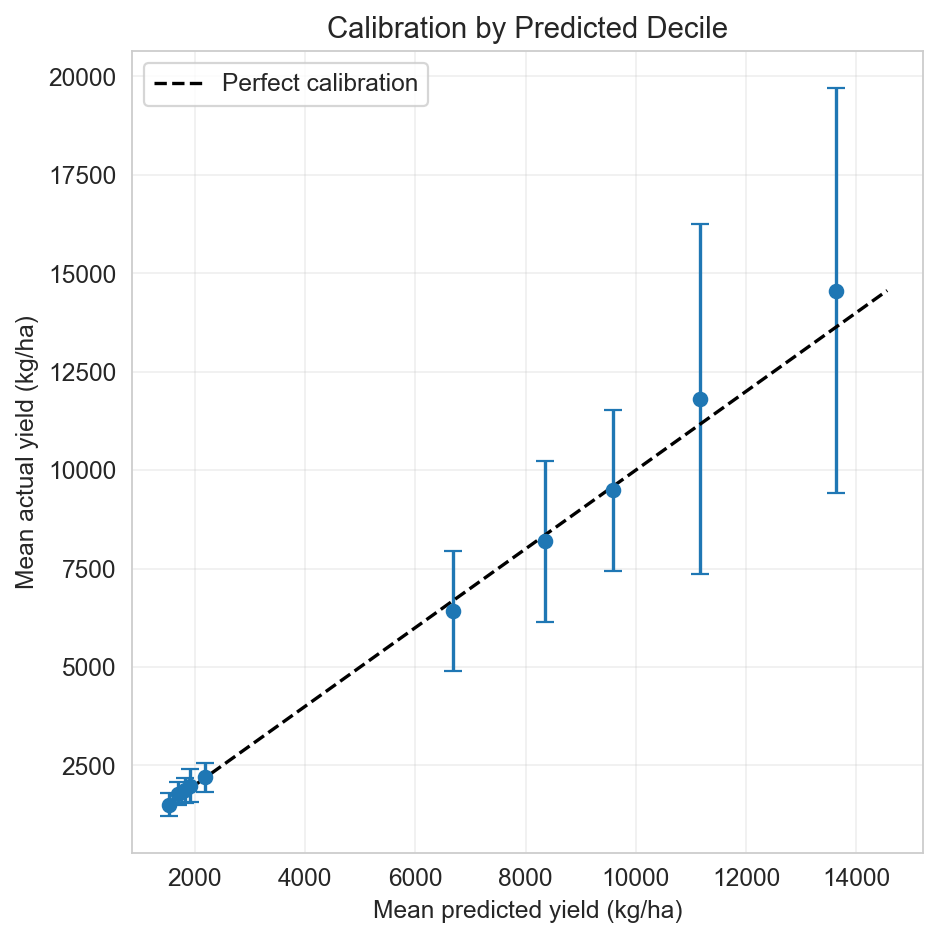

In [14]:
# Calibration plot and per-decile coverage
import matplotlib.pyplot as plt

# Build calibration frame if not present
cal_df = all_predictions_df.copy()
cal_df['Pred_Bin'] = pd.qcut(cal_df['Yield_Ensemble'], q=10, duplicates='drop')
cal_rows = []
for pred_bin, group in cal_df.groupby('Pred_Bin', observed=False):
    mean_pred = float(group['Yield_Ensemble'].mean())
    mean_act = float(group['Yield_True'].mean())
    std_act = float(group['Yield_True'].std())
    count = int(group.shape[0])
    inside = float(((group['Yield_True'] >= group['Yield_CI_Low']) & (group['Yield_True'] <= group['Yield_CI_High'])).mean())
    cal_rows.append({'Pred_Bin': str(pred_bin), 'Count': count, 'Mean_Predicted': mean_pred, 'Mean_Actual': mean_act, 'Std_Actual': std_act, 'Coverage': inside})

calibration_df = pd.DataFrame(cal_rows)
calibration_df.to_csv(RESULTS_DIR / 'tcn_mlp_eval_calibration_deciles.csv', index=False)

# Plot mean predicted vs mean actual with error bars
fig, ax = plt.subplots(figsize=(6,6))
ax.errorbar(calibration_df['Mean_Predicted'], calibration_df['Mean_Actual'], yerr=calibration_df['Std_Actual'], fmt='o', capsize=4)
minv = min(calibration_df['Mean_Predicted'].min(), calibration_df['Mean_Actual'].min())
maxv = max(calibration_df['Mean_Predicted'].max(), calibration_df['Mean_Actual'].max())
ax.plot([minv, maxv], [minv, maxv], 'k--', label='Perfect calibration')
ax.set_xlabel('Mean predicted yield (kg/ha)')
ax.set_ylabel('Mean actual yield (kg/ha)')
ax.set_title('Calibration by Predicted Decile')
ax.grid(alpha=0.3)
ax.legend()
fig.tight_layout()
plot_path = RESULTS_DIR / 'tcn_mlp_calibration_plot.png'
fig.savefig(plot_path, dpi=300, bbox_inches='tight')
print('Saved calibration plot to', plot_path)
calibration_df.head()